<a href="https://colab.research.google.com/github/kassmontezuma/Capstone/blob/DeepLearning/EntrenamientoDL.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import getpass

# 1. Configurar datos
USER = "kassmontezuma"
REPO = "Capstone"
TOKEN = getpass.getpass('Introduce tu GitHub Personal Access Token: ')

# 2. Clonamos el repositorio dentro de esta nueva máquina
!git clone https://{TOKEN}@github.com/{USER}/{REPO}.git

# 3. Nos movemos a la carpeta y cambiamos a tu rama
%cd {REPO}
!git checkout DeepLearning

Introduce tu GitHub Personal Access Token: ··········
Cloning into 'Capstone'...
remote: Enumerating objects: 217, done.
remote: Counting objects: 100% (19/19), done.
remote: Compressing objects: 100% (18/18), done.
remote: Total 217 (delta 4), reused 9 (delta 0), pack-reused 198 (from 1)
Receiving objects: 100% (217/217), 33.75 MiB | 9.16 MiB/s, done.
Resolving deltas: 100% (55/55), done.
/content/Capstone
Branch 'DeepLearning' set up to track remote branch 'DeepLearning' from 'origin'.
Switched to a new branch 'DeepLearning'


In [2]:
!git status

On branch DeepLearning
Your branch is up to date with 'origin/DeepLearning'.

nothing to commit, working tree clean


# Librerias

In [3]:
import os
import cv2
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
from torchvision import transforms
import torchvision.models as models
from torchvision.models import MobileNet_V2_Weights
from torchvision.models import DenseNet121_Weights
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    roc_curve
)

# Configuración

In [ ]:
SEED = 42
BATCH_SIZE = 32
NUM_EPOCHS = 20
LEARNING_RATE = 1e-4

# Fijar semillas para reproducibilidad
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed(SEED)
    torch.cuda.manual_seed_all(SEED)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {DEVICE}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")

Device: cuda
GPU: Tesla T4


# Montar drive

In [4]:
from google.colab import drive
drive.mount('/content/drive')

# Crear carpeta para guardar todo
SAVE_DIR = "/content/drive/MyDrive/INTRUSA JIJIJI/Modelos_DL"
!mkdir -p "{SAVE_DIR}/models"
!mkdir -p "{SAVE_DIR}/results"
!mkdir -p "{SAVE_DIR}/plots"
print(f"Archivos se guardarán en: {SAVE_DIR}")

Mounted at /content/drive
Archivos se guardarán en: /content/drive/MyDrive/INTRUSA JIJIJI/Modelos_DL


# Cargar dataset

In [ ]:
train_df = pd.read_csv("train_dataset.csv")
val_df = pd.read_csv("val_dataset.csv")
test_df = pd.read_csv("test_dataset.csv")

print(f"Train size: {len(train_df)}")
print(f"Val size: {len(val_df)}")
print(f"Test size: {len(test_df)}")

Train size: 3307
Val size: 688
Test size: 685


# Corregir rutas

In [ ]:
PATCH_DIR = "/content/drive/MyDrive/INTRUSA JIJIJI/patches_candidates"
train_df['path'] = train_df['path'].apply(
    lambda x: os.path.join(
        PATCH_DIR,
        os.path.basename(x.replace("\\", "/"))
    )
)
val_df['path'] = val_df['path'].apply(
    lambda x: os.path.join(
        PATCH_DIR,
        os.path.basename(x.replace("\\", "/"))
    )
)
test_df['path'] = test_df['path'].apply(
    lambda x: os.path.join(
        PATCH_DIR,
        os.path.basename(x.replace("\\", "/"))
    )
)
print(train_df.iloc[0]['path'])

/content/drive/MyDrive/INTRUSA JIJIJI/patches_candidates/1.3.6.1.4.1.14519.5.2.1.6279.6001.306140003699110313373771452136_363616_label0.npy


# Dataset class



In [ ]:
class LungCancerDataset(Dataset):
    def __init__(self, dataframe, patch_size=(64, 64, 64), target_size=(224, 224)):
        self.df = dataframe
        self.patch_size = patch_size
        self.target_size = target_size

        # Normalización para redes pre-entrenadas (ImageNet stats)
        self.normalize = transforms.Normalize(
            mean=[0.485, 0.456, 0.406],
            std=[0.229, 0.224, 0.225]
        )

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        # 1. Cargar patch 3D
        path = self.df.iloc[idx]['path']
        label = self.df.iloc[idx]['label']

        #Verifica que el archivo existe
        if not os.path.exists(path):
            print(f"Archivo no encontrado: {path}")
            # Retornar un patch dummy (esto no debería pasar si las rutas están bien)
            dummy_patch = np.zeros((64, 64, 64), dtype=np.float32)
            patch = dummy_patch
        else:
            patch = np.load(path)

        # 2. Extraer slices centrales de los 3 planos
        z_center, y_center, x_center = patch.shape[0]//2, patch.shape[1]//2, patch.shape[2]//2

        axial_slice = patch[z_center, :, :]      # plano axial (horizontal)
        coronal_slice = patch[:, y_center, :]    # plano coronal (frontal)
        sagital_slice = patch[:, :, x_center]    # plano sagital (lateral)

        # 3. Convertir a uint8 (0-255) para redimensionamiento con OpenCV
        # Porque tus valores están en [0,1] después del preprocessing
        axial = (axial_slice * 255).astype(np.uint8)
        coronal = (coronal_slice * 255).astype(np.uint8)
        sagital = (sagital_slice * 255).astype(np.uint8)

        # 4. Redimensionar a target_size (224x224)
        axial_resized = cv2.resize(axial, self.target_size, interpolation=cv2.INTER_LINEAR)
        coronal_resized = cv2.resize(coronal, self.target_size, interpolation=cv2.INTER_LINEAR)
        sagital_resized = cv2.resize(sagital, self.target_size, interpolation=cv2.INTER_LINEAR)

        # 5. Normalizar a [0,1] nuevamente (para convertir a tensor después)
        axial_norm = axial_resized / 255.0
        coronal_norm = coronal_resized / 255.0
        sagital_norm = sagital_resized / 255.0

        # 6. Stack como canales RGB (3, H, W)
        image = np.stack([axial_norm, coronal_norm, sagital_norm], axis=0)  # (3, 224, 224)

        # 7. Convertir a tensor y aplicar normalización ImageNet
        image = torch.from_numpy(image).float()
        image = self.normalize(image)

        # 8. Label (para clasificación binaria)
        label = torch.tensor(float(label), dtype=torch.float32)

        return image, label

# Crear datasets

In [ ]:
train_dataset = LungCancerDataset(train_df)
val_dataset = LungCancerDataset(val_df)
test_dataset = LungCancerDataset(test_df)

# Verificar sizes
print(f"Train size: {len(train_dataset)}")
print(f"Val size: {len(val_dataset)}")
print(f"Test size: {len(test_dataset)}")

Train size: 3307
Val size: 688
Test size: 685


# Verificar rutas

In [ ]:
def check_paths(df, name):
    missing = 0
    for idx, row in df.iterrows():
        if not os.path.exists(row['path']):
            missing += 1
            print(f"Missing: {row['path']}")
    print(f"{name}: {missing} archivos faltantes de {len(df)}")
    return missing

print("\nVerificando rutas...")
missing_train = check_paths(train_df, "Train")
missing_val = check_paths(val_df, "Val")
missing_test = check_paths(test_df, "Test")

if missing_train + missing_val + missing_test > 0:
    print("\nHay archivos faltantes. Revisa tus rutas en Drive.")
else:
    print("\nTodas las rutas son correctas!")


Verificando rutas...
Train: 0 archivos faltantes de 3307
Val: 0 archivos faltantes de 688
Test: 0 archivos faltantes de 685

Todas las rutas son correctas!


# Ejemplito


Ejemplo de datos:
  - Imagen shape: torch.Size([3, 224, 224])
  - Label: 0.0
  - Rango: [-2.12, 2.61]


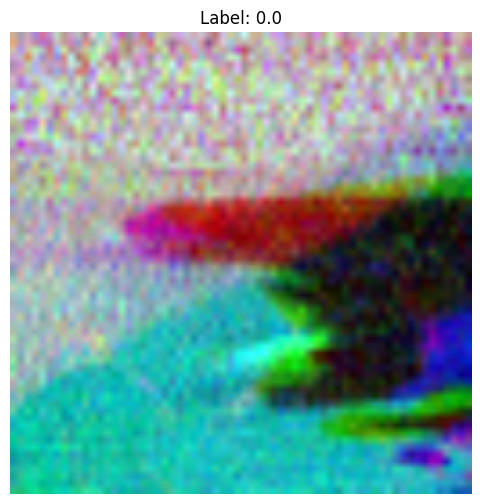

In [ ]:
sample_image, sample_label = train_dataset[0]
print(f"\nEjemplo de datos:")
print(f"  - Imagen shape: {sample_image.shape}")
print(f"  - Label: {sample_label}")
print(f"  - Rango: [{sample_image.min():.2f}, {sample_image.max():.2f}]")

def imshow(tensor, title=None):
    mean = torch.tensor([0.485, 0.456, 0.406]).view(3,1,1)
    std = torch.tensor([0.229, 0.224, 0.225]).view(3,1,1)
    tensor = tensor * std + mean
    tensor = torch.clamp(tensor, 0, 1)
    npimg = tensor.numpy().transpose(1,2,0)
    plt.imshow(npimg)
    if title:
        plt.title(title)
    plt.axis('off')

plt.figure(figsize=(6,6))
imshow(sample_image, f"Label: {sample_label.item()}")
plt.show()

# Crear dataloaders

In [ ]:
train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2,
    pin_memory=True,
    prefetch_factor=2
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

print("\nDataLoaders creados exitosamente")
print(f"  - Batches por epoch (train): {len(train_loader)}")
print(f"  - Batches por epoch (val): {len(val_loader)}")



DataLoaders creados exitosamente
  - Batches por epoch (train): 104
  - Batches por epoch (val): 22


# Probar un batch


Batch test:
  - Images shape: torch.Size([32, 3, 224, 224])
  - Labels shape: torch.Size([32])
  - Labels: tensor([0., 0., 0., 0., 0., 0., 0., 0., 0., 0.])
  - Image range: [-2.12, 2.64]


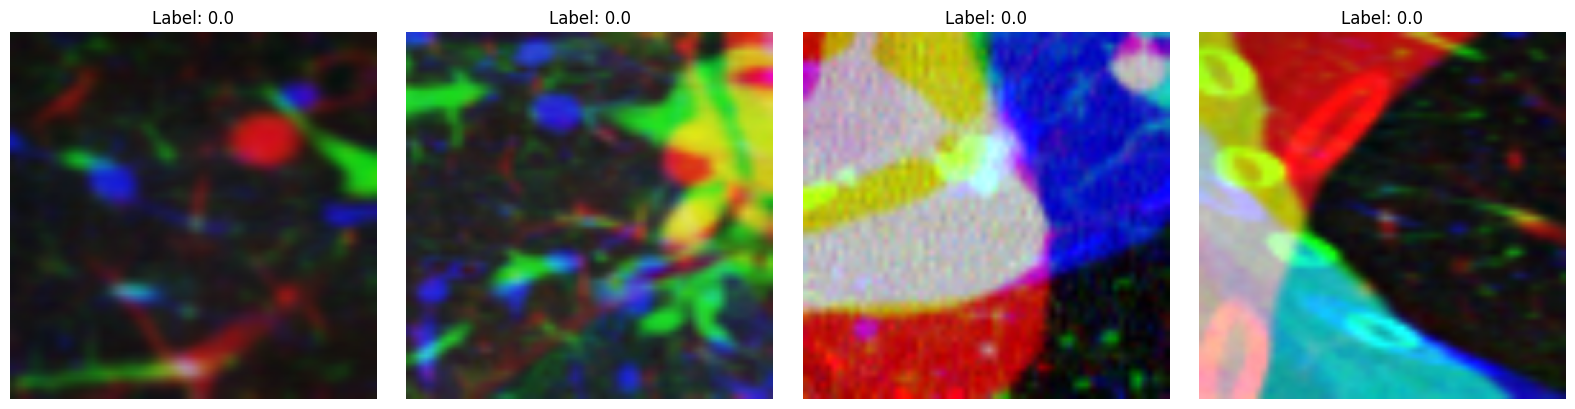

In [ ]:
images, labels = next(iter(train_loader))
print(f"\nBatch test:")
print(f"  - Images shape: {images.shape}")  # [32, 3, 224, 224]
print(f"  - Labels shape: {labels.shape}")  # [32]
print(f"  - Labels: {labels[:10]}")
print(f"  - Image range: [{images.min():.2f}, {images.max():.2f}]")

# Visualizar primeras 4 imágenes del batch
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for i in range(4):
    mean = torch.tensor([0.485, 0.456, 0.406]).view(3,1,1)
    std = torch.tensor([0.229, 0.224, 0.225]).view(3,1,1)
    img_display = images[i] * std + mean
    img_display = torch.clamp(img_display, 0, 1)

    axes[i].imshow(img_display.permute(1,2,0))
    axes[i].set_title(f"Label: {labels[i].item()}")
    axes[i].axis('off')
plt.tight_layout()
plt.show()


# Sanity check


Verificando DataLoaders...
   Batch shape: torch.Size([32, 3, 224, 224])
   Labels shape: torch.Size([32])
   Image range: [-2.12, 2.64]
   Label values: tensor([0., 1.])

Verificando balance de clases...
   Train - Positivos: 862/3307 (26.1%)
   Train - Negativos: 2445/3307 (73.9%)
   Val   - Positivos: 188/688 (27.3%)
   Test  - Positivos: 170/685 (24.8%)

Visualizando ejemplo de datos...


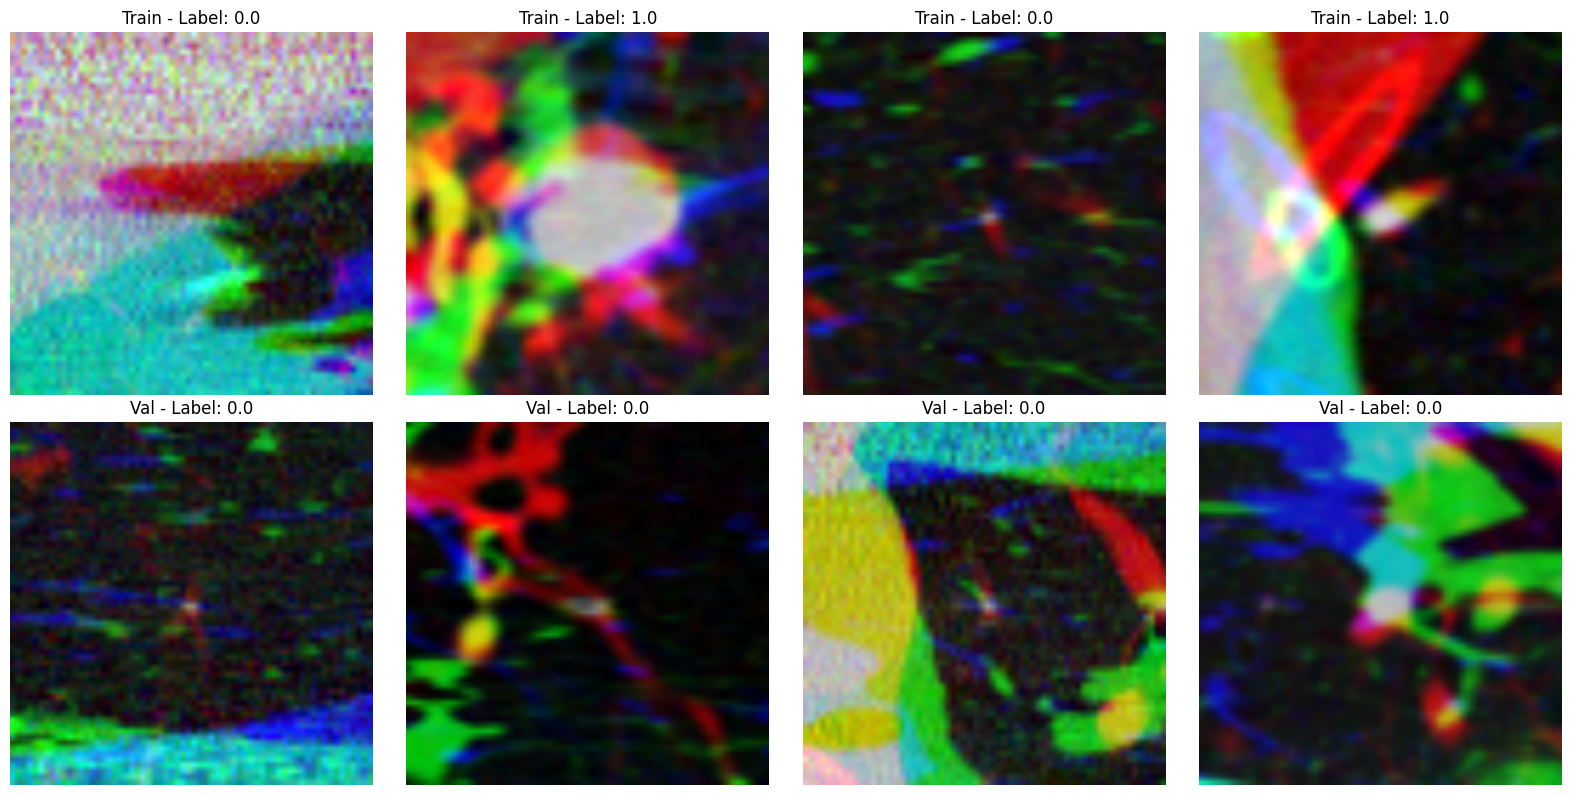


RESUMEN:
   - Device: cuda
   - Batch size: 32
   - Train samples: 3307
   - Val samples: 688
   - Test samples: 685
   - Clases balanceadas: 26.1% positivos

TODO LISTO PARA ENTRENAR LOS MODELOS


In [ ]:
# 1. Verificar que los DataLoaders funcionan
print("\nVerificando DataLoaders...")
try:
    sample_batch_images, sample_batch_labels = next(iter(train_loader))
    print(f"   Batch shape: {sample_batch_images.shape}")
    print(f"   Labels shape: {sample_batch_labels.shape}")
    print(f"   Image range: [{sample_batch_images.min():.2f}, {sample_batch_images.max():.2f}]")
    print(f"   Label values: {torch.unique(sample_batch_labels)}")
except Exception as e:
    print(f"   Error: {e}")
    raise

# 2. Verificar distribución de clases
print("\nVerificando balance de clases...")
train_labels = [train_df.iloc[i]['label'] for i in range(len(train_df))]
val_labels = [val_df.iloc[i]['label'] for i in range(len(val_df))]
test_labels = [test_df.iloc[i]['label'] for i in range(len(test_df))]

print(f"   Train - Positivos: {sum(train_labels)}/{len(train_labels)} ({100*sum(train_labels)/len(train_labels):.1f}%)")
print(f"   Train - Negativos: {len(train_labels)-sum(train_labels)}/{len(train_labels)} ({100*(len(train_labels)-sum(train_labels))/len(train_labels):.1f}%)")
print(f"   Val   - Positivos: {sum(val_labels)}/{len(val_labels)} ({100*sum(val_labels)/len(val_labels):.1f}%)")
print(f"   Test  - Positivos: {sum(test_labels)}/{len(test_labels)} ({100*sum(test_labels)/len(test_labels):.1f}%)")

# 3. Visualización de sanity check
print("\nVisualizando ejemplo de datos...")
fig, axes = plt.subplots(2, 4, figsize=(16, 8))

for i in range(4):
    # Imagen de entrenamiento
    img, label = train_dataset[i]
    mean = torch.tensor([0.485, 0.456, 0.406]).view(3,1,1)
    std = torch.tensor([0.229, 0.224, 0.225]).view(3,1,1)
    img_display = img * std + mean
    img_display = torch.clamp(img_display, 0, 1)

    axes[0, i].imshow(img_display.permute(1,2,0))
    axes[0, i].set_title(f"Train - Label: {label.item()}")
    axes[0, i].axis('off')

    # Imagen de validación
    img_val, label_val = val_dataset[i]
    img_val_display = img_val * std + mean
    img_val_display = torch.clamp(img_val_display, 0, 1)

    axes[1, i].imshow(img_val_display.permute(1,2,0))
    axes[1, i].set_title(f"Val - Label: {label_val.item()}")
    axes[1, i].axis('off')

plt.tight_layout()
plt.show()

print("\nRESUMEN:")
print(f"   - Device: {DEVICE}")
print(f"   - Batch size: {BATCH_SIZE}")
print(f"   - Train samples: {len(train_dataset)}")
print(f"   - Val samples: {len(val_dataset)}")
print(f"   - Test samples: {len(test_dataset)}")

print(
    f"   - Clases balanceadas: "
    f"{100*sum(train_labels)/len(train_labels):.1f}% positivos"
)

print("\nTODO LISTO PARA ENTRENAR LOS MODELOS")

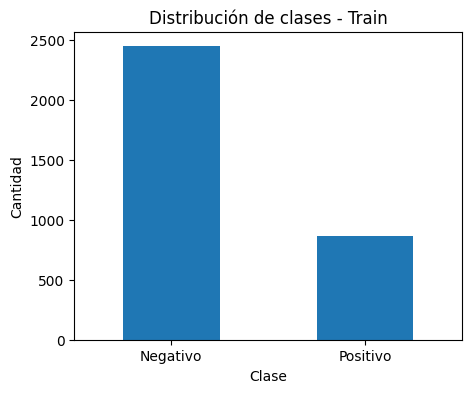

In [ ]:
import matplotlib.pyplot as plt

counts = train_df['label'].value_counts()

plt.figure(figsize=(5,4))
counts.plot(kind='bar')
plt.title("Distribución de clases - Train")
plt.xlabel("Clase")
plt.ylabel("Cantidad")
plt.xticks([0,1], ["Negativo", "Positivo"], rotation=0)
plt.show()

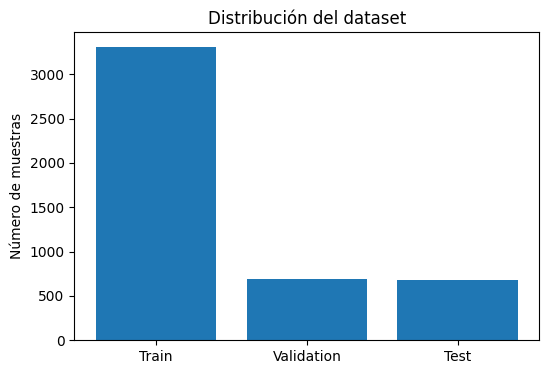

In [ ]:
splits = [
    len(train_df),
    len(val_df),
    len(test_df)
]

labels = [
    "Train",
    "Validation",
    "Test"
]

plt.figure(figsize=(6,4))
plt.bar(labels, splits)
plt.title("Distribución del dataset")
plt.ylabel("Número de muestras")
plt.show()

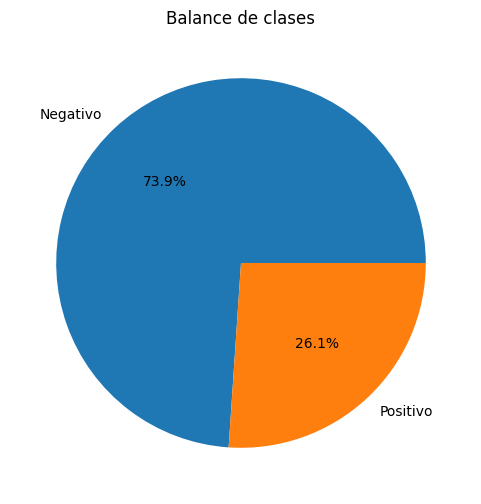

In [ ]:
plt.figure(figsize=(6,6))

train_df['label'].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%',
    labels=['Negativo','Positivo']
)

plt.ylabel("")
plt.title("Balance de clases")
plt.show()

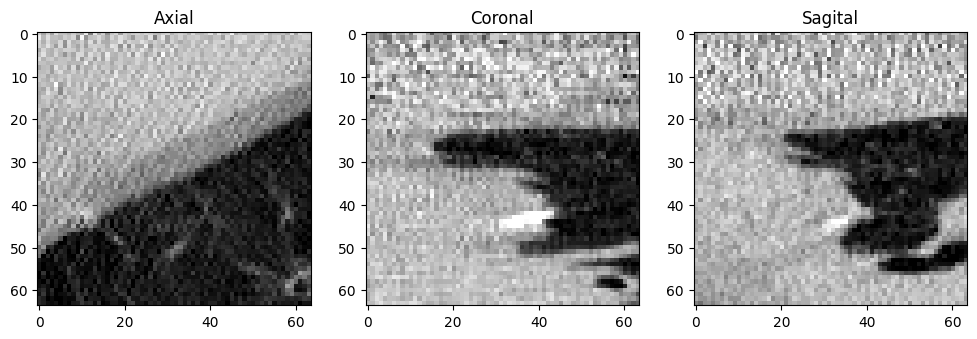

In [ ]:
patch = np.load(train_df.iloc[0]['path'])

z_center = patch.shape[0] // 2

plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
plt.imshow(
    patch[z_center,:,:],
    cmap='gray'
)
plt.title("Axial")

plt.subplot(1,3,2)
plt.imshow(
    patch[:,patch.shape[1]//2,:],
    cmap='gray'
)
plt.title("Coronal")

plt.subplot(1,3,3)
plt.imshow(
    patch[:,:,patch.shape[2]//2],
    cmap='gray'
)
plt.title("Sagital")

plt.show()

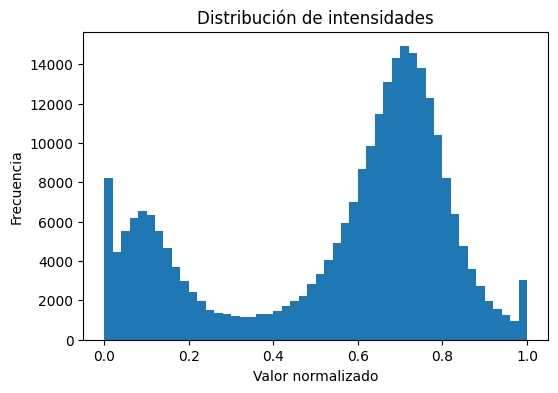

In [ ]:
patch = np.load(train_df.iloc[0]['path'])

plt.figure(figsize=(6,4))

plt.hist(
    patch.flatten(),
    bins=50
)

plt.title("Distribución de intensidades")
plt.xlabel("Valor normalizado")
plt.ylabel("Frecuencia")

plt.show()

In [ ]:
# Calcular el balance de clases en el dataset
train_labels = [train_df.iloc[i]['label'] for i in range(len(train_df))]
num_negatives = train_labels.count(0)  # Clase negativa (sin cáncer)
num_positives = train_labels.count(1)  # Clase positiva (con cáncer)

print(f"Negativos (0): {num_negatives}")
print(f"Positivos (1): {num_positives}")
print(f"Ratio neg/pos: {num_negatives/num_positives:.2f}")

# pos_weight = #negativos / #positivos
pos_weight_value = num_negatives / num_positives
print(f"pos_weight sugerido: {pos_weight_value:.4f}")

# Crear criterio con pos_weight
criterion = nn.BCEWithLogitsLoss(
    pos_weight=torch.tensor([pos_weight_value]).to(DEVICE)
)

Negativos (0): 2445
Positivos (1): 862
Ratio neg/pos: 2.84
pos_weight sugerido: 2.8364


# MOBILENETV2

In [ ]:
def create_mobilenetv2():
    model = models.mobilenet_v2(
        weights=MobileNet_V2_Weights.IMAGENET1K_V1
    )

    in_features = model.classifier[1].in_features

    model.classifier[1] = nn.Sequential(
        nn.Dropout(0.2),
        nn.Linear(in_features, 1)
    )

    return model

# Wrapper para asegurar salida 1D
class MobileNetV2Classifier(nn.Module):
    def __init__(self):
        super(MobileNetV2Classifier, self).__init__()
        self.backbone = create_mobilenetv2()

    def forward(self, x):
        x = self.backbone(x)
        return x.squeeze(1)  # (batch, 1) -> (batch,)

# Crear instancia
model = MobileNetV2Classifier().to(DEVICE)

# Ver arquitectura
print("Arquitectura MobileNetV2:")
print(f"  Total parameters: {sum(p.numel() for p in model.parameters()):,}")
print(f"  Trainable parameters: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}")

# Probar forward pass
test_input = torch.randn(2, 3, 224, 224).to(DEVICE)
test_output = model(test_input)
print(f"\nTest forward: input shape {test_input.shape} -> output shape {test_output.shape}")

# Calcular pos_weight
train_labels = [train_df.iloc[i]['label'] for i in range(len(train_df))]
num_neg = train_labels.count(0)
num_pos = train_labels.count(1)
pos_weight_value = num_neg / num_pos

print(f"\nBalance de clases:")
print(f"  Negativos (0): {num_neg}")
print(f"  Positivos (1): {num_pos}")
print(f"  pos_weight: {pos_weight_value:.4f}")

# Función de pérdida
criterion = nn.BCEWithLogitsLoss(
    pos_weight=torch.tensor([pos_weight_value]).to(DEVICE)
)

# Optimizador
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)

# Scheduler
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=3
)

print(f"\nConfiguración:")
print(f"  Device: {DEVICE}")
print(f"  Batch size: {BATCH_SIZE}")
print(f"  Learning rate: {LEARNING_RATE}")
print(f"  Epochs: {NUM_EPOCHS}")

Downloading: "https://download.pytorch.org/models/mobilenet_v2-b0353104.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v2-b0353104.pth


100%|██████████| 13.6M/13.6M [00:00<00:00, 202MB/s]


Arquitectura MobileNetV2:
  Total parameters: 2,225,153
  Trainable parameters: 2,225,153

Test forward: input shape torch.Size([2, 3, 224, 224]) -> output shape torch.Size([2])

Balance de clases:
  Negativos (0): 2445
  Positivos (1): 862
  pos_weight: 2.8364

Configuración:
  Device: cuda
  Batch size: 32
  Learning rate: 0.0001
  Epochs: 20


## Entrenamiento

In [ ]:
def train_epoch(model, loader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)  # Ahora ya es (batch,)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)

        # Precisión
        preds = (torch.sigmoid(outputs) > 0.5).float()
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    epoch_loss = running_loss / len(loader.dataset)
    epoch_acc = correct / total

    return epoch_loss, epoch_acc

def validate_epoch(model, loader, criterion, device):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0
    all_preds = []
    all_labels = []
    all_probs = []

    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)  # Ahora ya es (batch,)
            loss = criterion(outputs, labels)

            running_loss += loss.item() * images.size(0)

            probs = torch.sigmoid(outputs)
            preds = (probs > 0.5).float()
            correct += (preds == labels).sum().item()
            total += labels.size(0)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
            all_probs.extend(probs.cpu().numpy())

    epoch_loss = running_loss / len(loader.dataset)
    epoch_acc = correct / total

    return epoch_loss, epoch_acc, all_preds, all_labels, all_probs


In [ ]:
train_losses = []
val_losses = []
val_accuracies = []
best_val_loss = float('inf')
patience_counter = 0

for epoch in range(NUM_EPOCHS):
    # Entrenar
    train_loss, train_acc = train_epoch(model, train_loader, criterion, optimizer, DEVICE)

    # Validar
    val_loss, val_acc, preds, labels, probs = validate_epoch(model, val_loader, criterion, DEVICE)

    # Métricas adicionales
    from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix
    precision = precision_score(labels, preds, zero_division=0)
    recall = recall_score(labels, preds, zero_division=0)
    f1 = f1_score(labels, preds, zero_division=0)
    cm = confusion_matrix(labels, preds)
    tn, fp, fn, tp = cm.ravel()
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0

    # Guardar historial
    train_losses.append(train_loss)
    val_losses.append(val_loss)
    val_accuracies.append(val_acc)

    print(f"\nEpoch {epoch+1}/{NUM_EPOCHS}")
    print(f"  Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f}")
    print(f"  Val Loss:   {val_loss:.4f} | Val Acc:   {val_acc:.4f}")
    print(f"  Precision: {precision:.4f} | Sensibilidad: {recall:.4f} | Especificidad: {specificity:.4f} | F1: {f1:.4f}")

    # Learning rate scheduling
    scheduler.step(val_loss)

    # Early stopping
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        patience_counter = 0
        # Guardar mejor modelo
        torch.save({
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'val_loss': best_val_loss,
        },f'{SAVE_DIR}/models/best_mobilenetv2.pth')
    else:
        patience_counter += 1
        if patience_counter >= 7:
            print(f"  Early stopping en epoch {epoch+1}")
            break

    print("-" * 50)

print(f"\nMejor modelo con val_loss: {best_val_loss:.4f}")


Epoch 1/20
  Train Loss: 0.6694 | Train Acc: 0.7835
  Val Loss:   0.3533 | Val Acc:   0.9055
  Precision: 0.7971 | Sensibilidad: 0.8777 | Especificidad: 0.9160 | F1: 0.8354
--------------------------------------------------

Epoch 2/20
  Train Loss: 0.2451 | Train Acc: 0.9395
  Val Loss:   0.2761 | Val Acc:   0.9288
  Precision: 0.8601 | Sensibilidad: 0.8830 | Especificidad: 0.9460 | F1: 0.8714
--------------------------------------------------

Epoch 3/20
  Train Loss: 0.0877 | Train Acc: 0.9834
  Val Loss:   0.2873 | Val Acc:   0.9462
  Precision: 0.9218 | Sensibilidad: 0.8777 | Especificidad: 0.9720 | F1: 0.8992
--------------------------------------------------

Epoch 4/20
  Train Loss: 0.0263 | Train Acc: 0.9970
  Val Loss:   0.3205 | Val Acc:   0.9564
  Precision: 0.9540 | Sensibilidad: 0.8830 | Especificidad: 0.9840 | F1: 0.9171
--------------------------------------------------

Epoch 5/20
  Train Loss: 0.0226 | Train Acc: 0.9976
  Val Loss:   0.3148 | Val Acc:   0.9419
  Prec

## Visualización de resultados

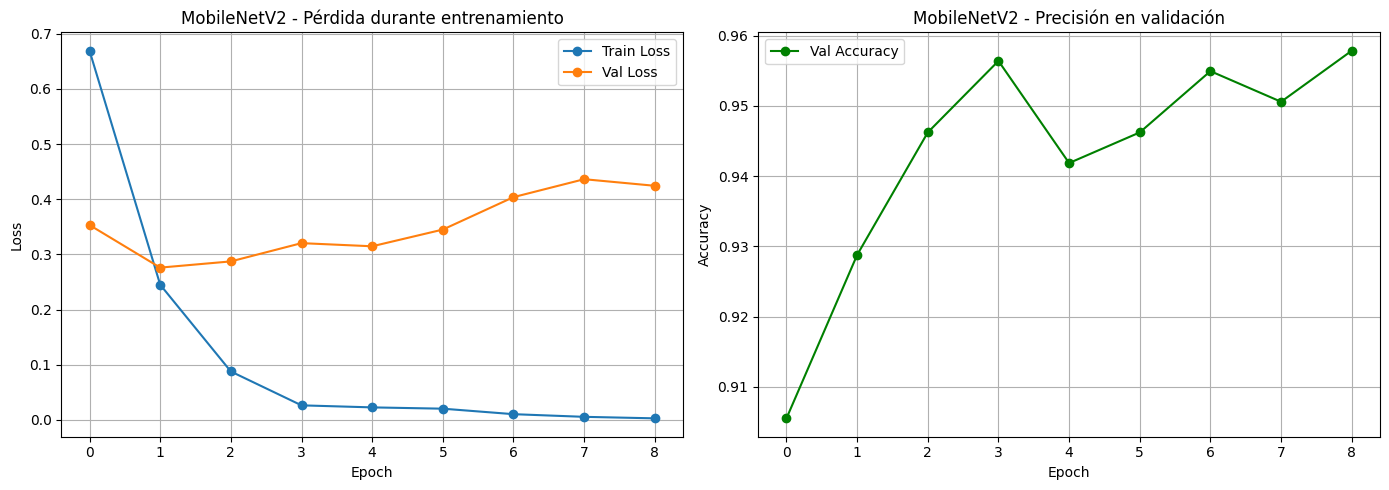

In [ ]:
# Graficar resultados
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Gráfico de pérdida
axes[0].plot(train_losses, label='Train Loss', marker='o')
axes[0].plot(val_losses, label='Val Loss', marker='o')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('MobileNetV2 - Pérdida durante entrenamiento')
axes[0].legend()
axes[0].grid(True)

# Gráfico de precisión
axes[1].plot(val_accuracies, label='Val Accuracy', marker='o', color='green')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].set_title('MobileNetV2 - Precisión en validación')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

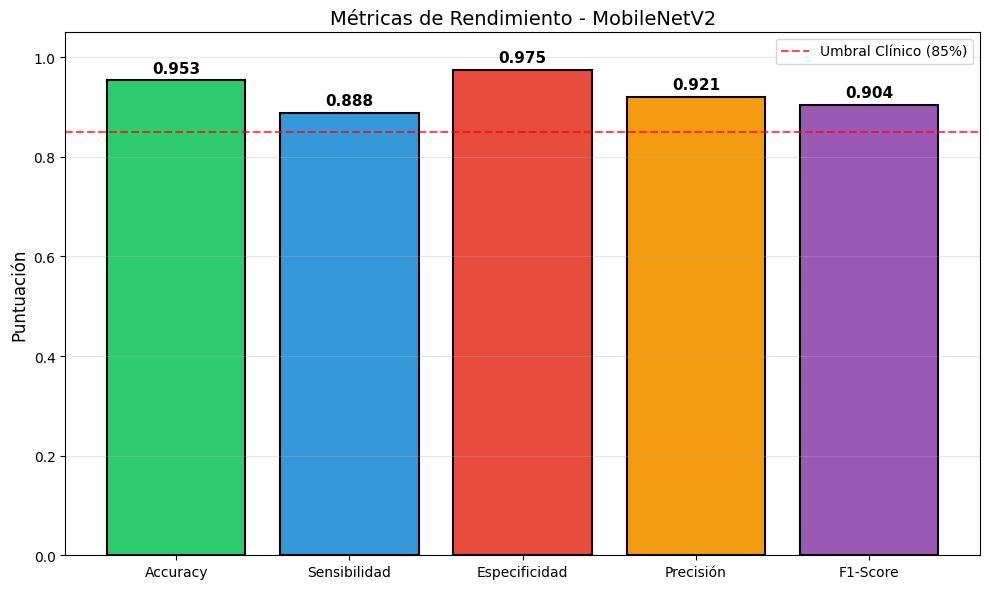

In [ ]:
metrics = ['Accuracy', 'Sensibilidad', 'Especificidad', 'Precisión', 'F1-Score']
values = [0.9533, 0.8882, 0.9748, 0.9207, 0.9042]
colors = ['#2ecc71', '#3498db', '#e74c3c', '#f39c12', '#9b59b6']

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.bar(metrics, values, color=colors, edgecolor='black', linewidth=1.5)
ax.set_ylim(0, 1.05)
ax.set_ylabel('Puntuación', fontsize=12)
ax.set_title('Métricas de Rendimiento - MobileNetV2', fontsize=14)
ax.axhline(y=0.85, color='red', linestyle='--', alpha=0.7, label='Umbral Clínico (85%)')

# Añadir valores en las barras
for bar, value in zip(bars, values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{value:.3f}', ha='center', va='bottom', fontweight='bold', fontsize=11)

ax.legend()
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

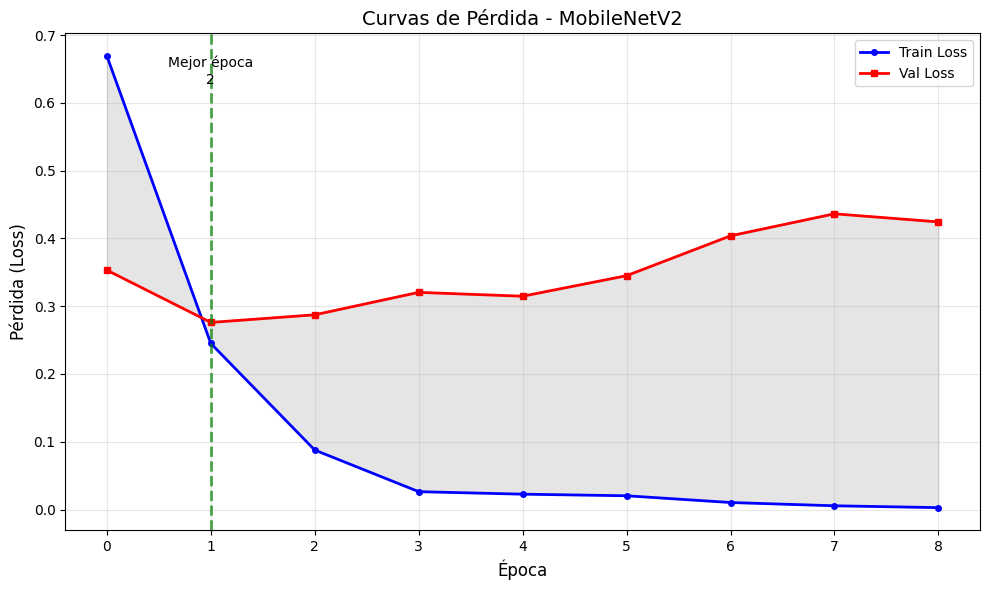

In [ ]:
fig, ax = plt.subplots(figsize=(10, 6))

# Pérdida de entrenamiento
ax.plot(train_losses, 'b-', linewidth=2, label='Train Loss', marker='o', markersize=4)
ax.plot(val_losses, 'r-', linewidth=2, label='Val Loss', marker='s', markersize=4)

# Rellenar área entre curvas
ax.fill_between(range(len(train_losses)), train_losses, val_losses, alpha=0.2, color='gray')

# Marcar mejor época
best_epoch = val_losses.index(min(val_losses))
ax.axvline(x=best_epoch, color='green', linestyle='--', linewidth=2, alpha=0.7)
ax.text(best_epoch, max(train_losses), f'Mejor época\n{best_epoch+1}',
        ha='center', va='top', fontsize=10)

ax.set_xlabel('Época', fontsize=12)
ax.set_ylabel('Pérdida (Loss)', fontsize=12)
ax.set_title('Curvas de Pérdida - MobileNetV2', fontsize=14)
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

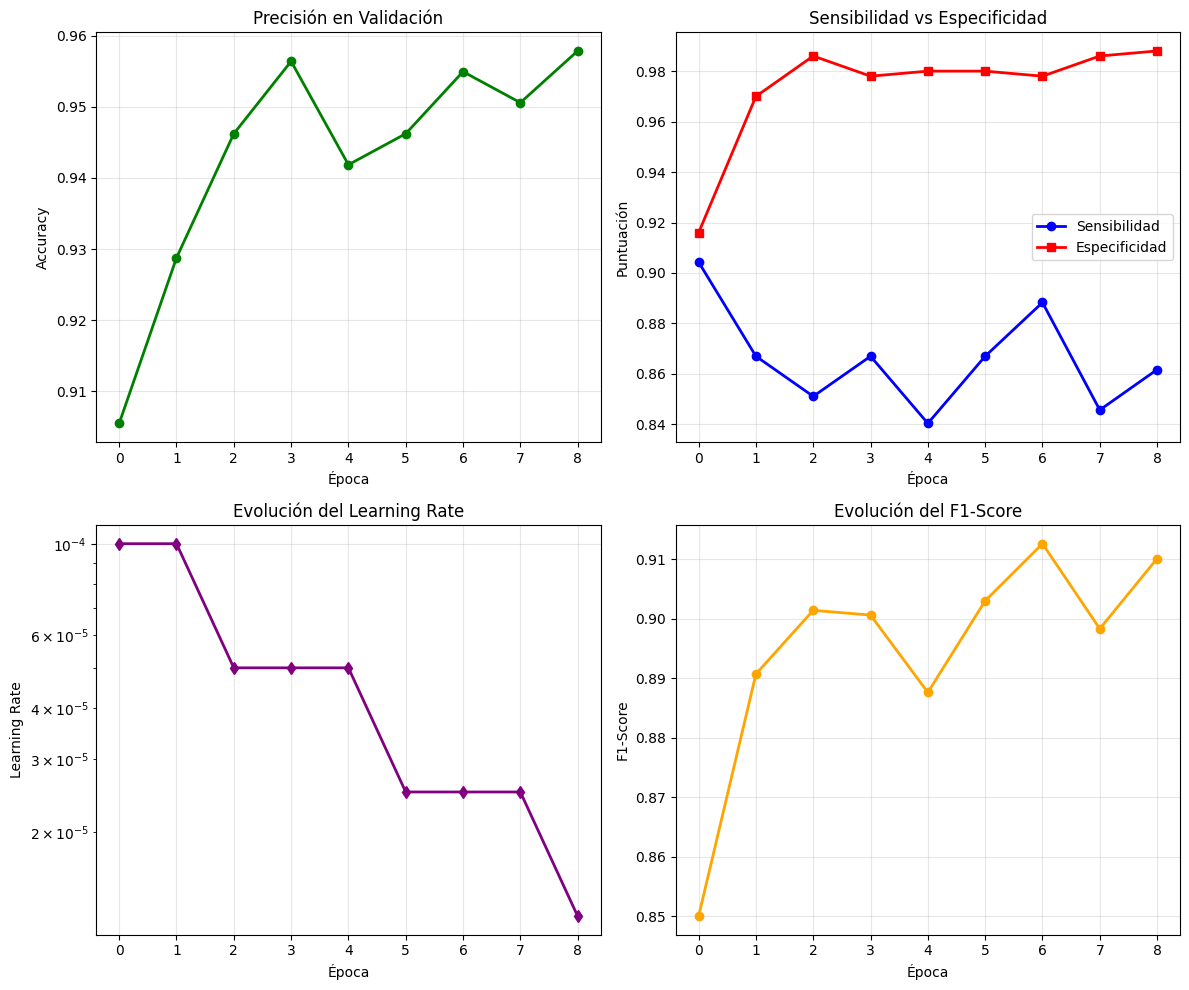

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# Accuracy
axes[0, 0].plot(val_accuracies, 'g-', linewidth=2, marker='o')
axes[0, 0].set_xlabel('Época')
axes[0, 0].set_ylabel('Accuracy')
axes[0, 0].set_title('Precisión en Validación')
axes[0, 0].grid(True, alpha=0.3)

# Sensibilidad y Especificidad (necesitas guardar estos valores)
sens = [0.9043, 0.8670, 0.8511, 0.8670, 0.8404, 0.8670, 0.8883, 0.8457, 0.8617]
spec = [0.9160, 0.9700, 0.9860, 0.9780, 0.9800, 0.9800, 0.9780, 0.9860, 0.9880]

axes[0, 1].plot(sens, 'b-', linewidth=2, label='Sensibilidad', marker='o')
axes[0, 1].plot(spec, 'r-', linewidth=2, label='Especificidad', marker='s')
axes[0, 1].set_xlabel('Época')
axes[0, 1].set_ylabel('Puntuación')
axes[0, 1].set_title('Sensibilidad vs Especificidad')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# Learning Rate (si guardaste los valores)
lrs = [1e-4, 1e-4, 5e-5, 5e-5, 5e-5, 2.5e-5, 2.5e-5, 2.5e-5, 1.25e-5]
axes[1, 0].plot(lrs[:len(train_losses)], 'purple', linewidth=2, marker='d')
axes[1, 0].set_xlabel('Época')
axes[1, 0].set_ylabel('Learning Rate')
axes[1, 0].set_yscale('log')
axes[1, 0].set_title('Evolución del Learning Rate')
axes[1, 0].grid(True, alpha=0.3)

# F1-Score por época
f1_scores = [0.8500, 0.8907, 0.9014, 0.9006, 0.8876, 0.9030, 0.9126, 0.8983, 0.9101]
axes[1, 1].plot(f1_scores, 'orange', linewidth=2, marker='o')
axes[1, 1].set_xlabel('Época')
axes[1, 1].set_ylabel('F1-Score')
axes[1, 1].set_title('Evolución del F1-Score')
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Evaluación en test

In [ ]:
# Cargar mejor modelo
checkpoint = torch.load(f'{SAVE_DIR}/models/best_mobilenetv2.pth')
model.load_state_dict(checkpoint['model_state_dict'])

# Evaluar en test
test_loss, test_acc, test_preds, test_labels, test_probs = validate_epoch(
    model, test_loader, criterion, DEVICE
)

print("RESULTADOS MOBILENET V2 - CONJUNTO DE TEST")

# Calcular métricas para test
test_precision = precision_score(test_labels, test_preds, zero_division=0)
test_recall = recall_score(test_labels, test_preds, zero_division=0)
test_f1 = f1_score(test_labels, test_preds, zero_division=0)
test_auc = roc_auc_score(test_labels, test_probs)
cm_test = confusion_matrix(test_labels, test_preds)
tn, fp, fn, tp = cm_test.ravel()
test_specificity = tn / (tn + fp) if (tn + fp) > 0 else 0

print(f"  Loss:         {test_loss:.4f}")
print(f"  Accuracy:     {test_acc:.4f}")
print(f"  Precision:    {test_precision:.4f}")
print(f"  Recall (Sensibilidad): {test_recall:.4f}")
print(f"  Especificidad: {test_specificity:.4f}")
print(f"  F1-Score:     {test_f1:.4f}")
print(f"  AUC-ROC:      {test_auc:.4f}")

print(f"\nMatriz de confusión:")
print(f"    TN: {cm_test[0,0]}  FP: {cm_test[0,1]}")
print(f"    FN: {cm_test[1,0]}  TP: {cm_test[1,1]}")

# Mostrar porcentajes
print(f"\nPorcentajes:")
print(f"    Sensibilidad (TPR): {test_recall*100:.2f}%")
print(f"    Especificidad (TNR): {test_specificity*100:.2f}%")
print(f"    Precisión (PPV): {test_precision*100:.2f}%")

RESULTADOS MOBILENET V2 - CONJUNTO DE TEST
  Loss:         0.2979
  Accuracy:     0.9416
  Precision:    0.8869
  Recall (Sensibilidad): 0.8765
  Especificidad: 0.9631
  F1-Score:     0.8817
  AUC-ROC:      0.9775

Matriz de confusión:
    TN: 496  FP: 19
    FN: 21  TP: 149

Porcentajes:
    Sensibilidad (TPR): 87.65%
    Especificidad (TNR): 96.31%
    Precisión (PPV): 88.69%


In [ ]:
# CELDA MÁGICA - Guarda todo automáticamente
import json
import pandas as pd

# Resultados de MobileNetV2
mobilenet_results = {
    'model': 'MobileNetV2',
    'accuracy': test_acc,
    'precision': test_precision,
    'recall': test_recall,
    'specificity': test_specificity,
    'f1_score': test_f1,
    'auc_roc': test_auc,
    'tn': int(cm_test[0,0]),
    'fp': int(cm_test[0,1]),
    'fn': int(cm_test[1,0]),
    'tp': int(cm_test[1,1])
}

# Guardar como DataFrame
df_results = pd.DataFrame([mobilenet_results])
df_results.to_csv(f'{SAVE_DIR}/results/MobileNetV2_results.csv', index=False)

# También guardar como JSON
with open(f'{SAVE_DIR}/results/MobileNetV2_results.json', 'w') as f:
    json.dump(mobilenet_results, f, indent=4)

print("Resultados de MobileNetV2 guardados automáticamente!")
print("Archivos creados: MobileNetV2_results.csv y MobileNetV2_results.json")

Resultados de MobileNetV2 guardados automáticamente!
Archivos creados: MobileNetV2_results.csv y MobileNetV2_results.json


# DENSENET121

In [ ]:
# Limpiar memoria antes de entrenar nuevo modelo
torch.cuda.empty_cache()
import gc
gc.collect()

# DENSENET121
class DenseNet121Classifier(nn.Module):
    def __init__(self):
        super(DenseNet121Classifier, self).__init__()
        self.backbone = models.densenet121(weights=DenseNet121_Weights.IMAGENET1K_V1)
        in_features = self.backbone.classifier.in_features
        self.backbone.classifier = nn.Linear(in_features, 1)

    def forward(self, x):
        return self.backbone(x).squeeze(1)

# Crear modelo
model_densenet = DenseNet121Classifier().to(DEVICE)

print("Arquitectura DenseNet121:")
print(f"  Total parameters: {sum(p.numel() for p in model_densenet.parameters()):,}")
print(f"  Trainable parameters: {sum(p.numel() for p in model_densenet.parameters() if p.requires_grad):,}")

# Probar forward pass
test_input = torch.randn(2, 3, 224, 224).to(DEVICE)
test_output = model_densenet(test_input)
print(f"\nTest forward: input shape {test_input.shape} -> output shape {test_output.shape}")

# Calcular pos_weight (mismo que antes)
train_labels = [train_df.iloc[i]['label'] for i in range(len(train_df))]
num_neg = train_labels.count(0)
num_pos = train_labels.count(1)
pos_weight_value = num_neg / num_pos

print(f"\nBalance de clases:")
print(f"  Negativos (0): {num_neg}")
print(f"  Positivos (1): {num_pos}")
print(f"  pos_weight: {pos_weight_value:.4f}")

# Función de pérdida
criterion = nn.BCEWithLogitsLoss(
    pos_weight=torch.tensor([pos_weight_value]).to(DEVICE)
)

# Optimizador (learning rate más bajo para modelo más grande)
optimizer_densenet = torch.optim.Adam(model_densenet.parameters(), lr=LEARNING_RATE)
scheduler_densenet = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer_densenet, mode='min', factor=0.5, patience=3
)

print(f"\nConfiguración:")
print(f"  Device: {DEVICE}")
print(f"  Batch size: {BATCH_SIZE}")
print(f"  Learning rate: {LEARNING_RATE}")
print(f"  Epochs: {NUM_EPOCHS}")

Downloading: "https://download.pytorch.org/models/densenet121-a639ec97.pth" to /root/.cache/torch/hub/checkpoints/densenet121-a639ec97.pth


100%|██████████| 30.8M/30.8M [00:00<00:00, 183MB/s]


Arquitectura DenseNet121:
  Total parameters: 6,954,881
  Trainable parameters: 6,954,881

Test forward: input shape torch.Size([2, 3, 224, 224]) -> output shape torch.Size([2])

Balance de clases:
  Negativos (0): 2445
  Positivos (1): 862
  pos_weight: 2.8364

Configuración:
  Device: cuda
  Batch size: 32
  Learning rate: 0.0001
  Epochs: 20


## Entrenamiento

In [ ]:
train_losses_dense = []
val_losses_dense = []
val_accuracies_dense = []
best_val_loss_dense = float('inf')
patience_counter_dense = 0

for epoch in range(NUM_EPOCHS):
    # Entrenar
    train_loss, train_acc = train_epoch(model_densenet, train_loader, criterion, optimizer_densenet, DEVICE)

    # Validar
    val_loss, val_acc, preds, labels, probs = validate_epoch(model_densenet, val_loader, criterion, DEVICE)

    # Métricas adicionales
    from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix
    precision = precision_score(labels, preds, zero_division=0)
    recall = recall_score(labels, preds, zero_division=0)
    f1 = f1_score(labels, preds, zero_division=0)
    cm = confusion_matrix(labels, preds)
    tn, fp, fn, tp = cm.ravel()
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0

    # Guardar historial
    train_losses_dense.append(train_loss)
    val_losses_dense.append(val_loss)
    val_accuracies_dense.append(val_acc)

    print(f"\nEpoch {epoch+1}/{NUM_EPOCHS}")
    print(f"  Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f}")
    print(f"  Val Loss:   {val_loss:.4f} | Val Acc:   {val_acc:.4f}")
    print(f"  Precision: {precision:.4f} | Sensibilidad: {recall:.4f} | Especificidad: {specificity:.4f} | F1: {f1:.4f}")

    # Learning rate scheduling
    scheduler_densenet.step(val_loss)

    # Early stopping
    if val_loss < best_val_loss_dense:
        best_val_loss_dense = val_loss
        patience_counter_dense = 0
        # Guardar mejor modelo
        torch.save({
            'epoch': epoch,
            'model_state_dict': model_densenet.state_dict(),
            'optimizer_state_dict': optimizer_densenet.state_dict(),
            'val_loss': best_val_loss_dense,
        },f'{SAVE_DIR}/models/best_densenet121.pth')
    else:
        patience_counter_dense += 1
        if patience_counter_dense >= 7:
            print(f"Early stopping en epoch {epoch+1}")
            break

print(f"\nMejor modelo DenseNet121 con val_loss: {best_val_loss_dense:.4f}")


Epoch 1/20
  Train Loss: 0.5779 | Train Acc: 0.7883
  Val Loss:   0.3088 | Val Acc:   0.9375
  Precision: 0.8919 | Sensibilidad: 0.8777 | Especificidad: 0.9600 | F1: 0.8847

Epoch 2/20
  Train Loss: 0.1796 | Train Acc: 0.9628
  Val Loss:   0.3395 | Val Acc:   0.9433
  Precision: 0.9209 | Sensibilidad: 0.8670 | Especificidad: 0.9720 | F1: 0.8932

Epoch 3/20
  Train Loss: 0.0873 | Train Acc: 0.9837
  Val Loss:   0.2446 | Val Acc:   0.9622
  Precision: 0.9402 | Sensibilidad: 0.9202 | Especificidad: 0.9780 | F1: 0.9301

Epoch 4/20
  Train Loss: 0.0348 | Train Acc: 0.9958
  Val Loss:   0.2783 | Val Acc:   0.9535
  Precision: 0.9105 | Sensibilidad: 0.9202 | Especificidad: 0.9660 | F1: 0.9153

Epoch 5/20
  Train Loss: 0.0231 | Train Acc: 0.9964
  Val Loss:   0.3593 | Val Acc:   0.9578
  Precision: 0.9492 | Sensibilidad: 0.8936 | Especificidad: 0.9820 | F1: 0.9205

Epoch 6/20
  Train Loss: 0.0136 | Train Acc: 0.9982
  Val Loss:   0.5034 | Val Acc:   0.9564
  Precision: 0.9938 | Sensibilidad: 

## Visualizacion de resultados

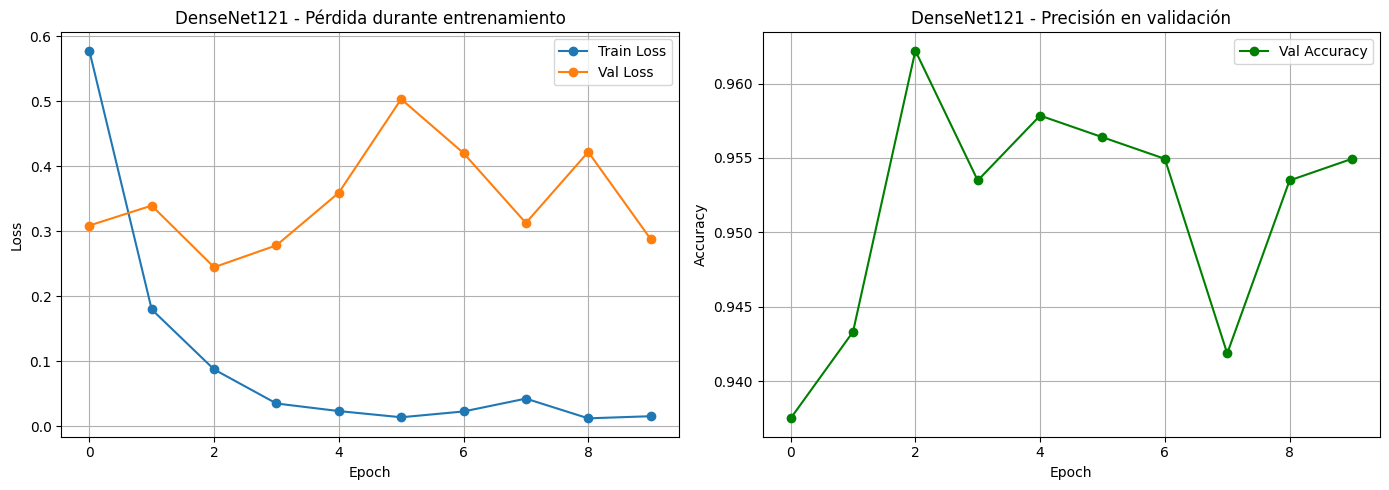

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Gráfico de pérdida
axes[0].plot(train_losses_dense, label='Train Loss', marker='o')
axes[0].plot(val_losses_dense, label='Val Loss', marker='o')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('DenseNet121 - Pérdida durante entrenamiento')
axes[0].legend()
axes[0].grid(True)

# Gráfico de precisión
axes[1].plot(val_accuracies_dense, label='Val Accuracy', marker='o', color='green')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].set_title('DenseNet121 - Precisión en validación')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

## Evaluación en test

In [ ]:
# Cargar mejor modelo
checkpoint = torch.load(f'{SAVE_DIR}/models/best_mobilenetv2.pth')
checkpoint = torch.load('best_densenet121.pth')
model_densenet.load_state_dict(checkpoint['model_state_dict'])

# Evaluar en test
test_loss_dense, test_acc_dense, test_preds_dense, test_labels_dense, test_probs_dense = validate_epoch(
    model_densenet, test_loader, criterion, DEVICE
)

# Calcular métricas para test
test_precision_dense = precision_score(test_labels_dense, test_preds_dense, zero_division=0)
test_recall_dense = recall_score(test_labels_dense, test_preds_dense, zero_division=0)
test_f1_dense = f1_score(test_labels_dense, test_preds_dense, zero_division=0)
test_auc_dense = roc_auc_score(test_labels_dense, test_probs_dense)
cm_test_dense = confusion_matrix(test_labels_dense, test_preds_dense)
tn, fp, fn, tp = cm_test_dense.ravel()
test_specificity_dense = tn / (tn + fp) if (tn + fp) > 0 else 0

print(f"  Loss:         {test_loss_dense:.4f}")
print(f"  Accuracy:     {test_acc_dense:.4f}")
print(f"  Precision:    {test_precision_dense:.4f}")
print(f"  Recall (Sensibilidad): {test_recall_dense:.4f}")
print(f"  Especificidad: {test_specificity_dense:.4f}")
print(f"  F1-Score:     {test_f1_dense:.4f}")
print(f"  AUC-ROC:      {test_auc_dense:.4f}")

print(f"\nMatriz de confusión:")
print(f"    TN: {cm_test_dense[0,0]}  FP: {cm_test_dense[0,1]}")
print(f"    FN: {cm_test_dense[1,0]}  TP: {cm_test_dense[1,1]}")

print(f"\nPorcentajes:")
print(f"    Sensibilidad (TPR): {test_recall_dense*100:.2f}%")
print(f"    Especificidad (TNR): {test_specificity_dense*100:.2f}%")
print(f"    Precisión (PPV): {test_precision_dense*100:.2f}%")

  Loss:         0.2801
  Accuracy:     0.9416
  Precision:    0.8652
  Recall (Sensibilidad): 0.9059
  Especificidad: 0.9534
  F1-Score:     0.8851
  AUC-ROC:      0.9745

Matriz de confusión:
    TN: 491  FP: 24
    FN: 16  TP: 154

Porcentajes:
    Sensibilidad (TPR): 90.59%
    Especificidad (TNR): 95.34%
    Precisión (PPV): 86.52%


In [ ]:
# Cargar mejor modelo
checkpoint = torch.load(f'{SAVE_DIR}/models/best_densenet121.pth')
model_densenet.load_state_dict(checkpoint['model_state_dict'])

# Evaluar en test
test_loss_dense, test_acc_dense, test_preds_dense, test_labels_dense, test_probs_dense = validate_epoch(
    model_densenet, test_loader, criterion, DEVICE
)

# Calcular métricas para test
test_precision_dense = precision_score(test_labels_dense, test_preds_dense, zero_division=0)
test_recall_dense = recall_score(test_labels_dense, test_preds_dense, zero_division=0)
test_f1_dense = f1_score(test_labels_dense, test_preds_dense, zero_division=0)
test_auc_dense = roc_auc_score(test_labels_dense, test_probs_dense)
cm_test_dense = confusion_matrix(test_labels_dense, test_preds_dense)
tn, fp, fn, tp = cm_test_dense.ravel()
test_specificity_dense = tn / (tn + fp) if (tn + fp) > 0 else 0

print(f"  Loss:         {test_loss_dense:.4f}")
print(f"  Accuracy:     {test_acc_dense:.4f}")
print(f"  Precision:    {test_precision_dense:.4f}")
print(f"  Recall (Sensibilidad): {test_recall_dense:.4f}")
print(f"  Especificidad: {test_specificity_dense:.4f}")
print(f"  F1-Score:     {test_f1_dense:.4f}")
print(f"  AUC-ROC:      {test_auc_dense:.4f}")

print(f"\nMatriz de confusión:")
print(f"    TN: {cm_test_dense[0,0]}  FP: {cm_test_dense[0,1]}")
print(f"    FN: {cm_test_dense[1,0]}  TP: {cm_test_dense[1,1]}")

print(f"\nPorcentajes:")
print(f"    Sensibilidad (TPR): {test_recall_dense*100:.2f}%")
print(f"    Especificidad (TNR): {test_specificity_dense*100:.2f}%")
print(f"    Precisión (PPV): {test_precision_dense*100:.2f}%")

  Loss:         0.2431
  Accuracy:     0.9518
  Precision:    0.8960
  Recall (Sensibilidad): 0.9118
  Especificidad: 0.9650
  F1-Score:     0.9038
  AUC-ROC:      0.9829

Matriz de confusión:
    TN: 497  FP: 18
    FN: 15  TP: 155

Porcentajes:
    Sensibilidad (TPR): 91.18%
    Especificidad (TNR): 96.50%
    Precisión (PPV): 89.60%


In [ ]:
import json
import pandas as pd

densenet_results = {
    'model': 'DenseNet121',
    'accuracy': test_acc_dense,
    'precision': test_precision_dense,
    'recall': test_recall_dense,
    'specificity': test_specificity_dense,
    'f1_score': test_f1_dense,
    'auc_roc': test_auc_dense,
    'tn': int(cm_test_dense[0,0]),
    'fp': int(cm_test_dense[0,1]),
    'fn': int(cm_test_dense[1,0]),
    'tp': int(cm_test_dense[1,1])
}
# Guardar como DataFrame
df_results = pd.DataFrame([densenet_results])
df_results.to_csv(f'{SAVE_DIR}/results/DenseNet121_results.csv', index=False)

# También guardar como JSON
with open(f'{SAVE_DIR}/results/DenseNet121_results.json', 'w') as f:
    json.dump(densenet_results, f, indent=4)

print("Resultados de DenseNet121 guardados automáticamente!")
print("Archivos creados: DenseNet121_results.csv y DenseNet121_results.json")

Resultados de DenseNet121 guardados automáticamente!
Archivos creados: DenseNet121_results.csv y DenseNet121_results.json


# EFFICIENTNET-B0

In [ ]:
from torchvision.models import EfficientNet_B0_Weights

# Limpiar memoria antes de entrenar nuevo modelo
torch.cuda.empty_cache()
import gc
gc.collect()

# EFFICIENTNET-B0
class EfficientNetB0Classifier(nn.Module):
    def __init__(self):
        super(EfficientNetB0Classifier, self).__init__()
        self.backbone = models.efficientnet_b0(weights=EfficientNet_B0_Weights.IMAGENET1K_V1)
        in_features = self.backbone.classifier[1].in_features
        self.backbone.classifier[1] = nn.Linear(in_features, 1)

    def forward(self, x):
        return self.backbone(x).squeeze(1)

# Crear modelo
model_efficientnet = EfficientNetB0Classifier().to(DEVICE)

print("Arquitectura EfficientNet-B0:")
print(f"  Total parameters: {sum(p.numel() for p in model_efficientnet.parameters()):,}")
print(f"  Trainable parameters: {sum(p.numel() for p in model_efficientnet.parameters() if p.requires_grad):,}")

# Probar forward pass
test_input = torch.randn(2, 3, 224, 224).to(DEVICE)
test_output = model_efficientnet(test_input)
print(f"\nTest forward: input shape {test_input.shape} -> output shape {test_output.shape}")

# Calcular pos_weight (mismo que antes)
train_labels = [train_df.iloc[i]['label'] for i in range(len(train_df))]
num_neg = train_labels.count(0)
num_pos = train_labels.count(1)
pos_weight_value = num_neg / num_pos

print(f"\nBalance de clases:")
print(f"  Negativos (0): {num_neg}")
print(f"  Positivos (1): {num_pos}")
print(f"  pos_weight: {pos_weight_value:.4f}")

# Función de pérdida
criterion = nn.BCEWithLogitsLoss(
    pos_weight=torch.tensor([pos_weight_value]).to(DEVICE)
)

# Optimizador
optimizer_efficientnet = torch.optim.Adam(model_efficientnet.parameters(), lr=LEARNING_RATE)
scheduler_efficientnet = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer_efficientnet, mode='min', factor=0.5, patience=3
)

print(f"\nConfiguración:")
print(f"  Device: {DEVICE}")
print(f"  Batch size: {BATCH_SIZE}")
print(f"  Learning rate: {LEARNING_RATE}")
print(f"  Epochs: {NUM_EPOCHS}")

Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 46.9MB/s]


Arquitectura EfficientNet-B0:
  Total parameters: 4,008,829
  Trainable parameters: 4,008,829

Test forward: input shape torch.Size([2, 3, 224, 224]) -> output shape torch.Size([2])

Balance de clases:
  Negativos (0): 2445
  Positivos (1): 862
  pos_weight: 2.8364

Configuración:
  Device: cuda
  Batch size: 32
  Learning rate: 0.0001
  Epochs: 20


## Entrenamiento

In [ ]:
train_losses_efficient = []
val_losses_efficient = []
val_accuracies_efficient = []
best_val_loss_efficient = float('inf')
patience_counter_efficient = 0

for epoch in range(NUM_EPOCHS):
    # Entrenar
    train_loss, train_acc = train_epoch(model_efficientnet, train_loader, criterion, optimizer_efficientnet, DEVICE)

    # Validar
    val_loss, val_acc, preds, labels, probs = validate_epoch(model_efficientnet, val_loader, criterion, DEVICE)

    # Métricas adicionales
    from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix
    precision = precision_score(labels, preds, zero_division=0)
    recall = recall_score(labels, preds, zero_division=0)
    f1 = f1_score(labels, preds, zero_division=0)
    cm = confusion_matrix(labels, preds)
    tn, fp, fn, tp = cm.ravel()
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0

    # Guardar historial
    train_losses_efficient.append(train_loss)
    val_losses_efficient.append(val_loss)
    val_accuracies_efficient.append(val_acc)

    print(f"\nEpoch {epoch+1}/{NUM_EPOCHS}")
    print(f"  Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f}")
    print(f"  Val Loss:   {val_loss:.4f} | Val Acc:   {val_acc:.4f}")
    print(f"  Precision: {precision:.4f} | Sensibilidad: {recall:.4f} | Especificidad: {specificity:.4f} | F1: {f1:.4f}")

    # Learning rate scheduling
    scheduler_efficientnet.step(val_loss)

    # Early stopping
    if val_loss < best_val_loss_efficient:
        best_val_loss_efficient = val_loss
        patience_counter_efficient = 0
        # Guardar mejor modelo
        torch.save({
            'epoch': epoch,
            'model_state_dict': model_efficientnet.state_dict(),
            'optimizer_state_dict': optimizer_efficientnet.state_dict(),
            'val_loss': best_val_loss_efficient,
        },f'{SAVE_DIR}/models/best_EfficientNet-B0.pth')
    else:
        patience_counter_efficient += 1
        if patience_counter_efficient >= 7:
            print(f"Early stopping en epoch {epoch+1}")
            break

print(f"\nMejor modelo EfficientNet-B0 con val_loss: {best_val_loss_efficient:.4f}")


Epoch 1/20
  Train Loss: 0.8744 | Train Acc: 0.6816
  Val Loss:   0.5234 | Val Acc:   0.8227
  Precision: 0.6231 | Sensibilidad: 0.8883 | Especificidad: 0.7980 | F1: 0.7325

Epoch 2/20
  Train Loss: 0.4008 | Train Acc: 0.9041
  Val Loss:   0.3087 | Val Acc:   0.9506
  Precision: 0.9231 | Sensibilidad: 0.8936 | Especificidad: 0.9720 | F1: 0.9081

Epoch 3/20
  Train Loss: 0.1971 | Train Acc: 0.9580
  Val Loss:   0.2987 | Val Acc:   0.9520
  Precision: 0.9480 | Sensibilidad: 0.8723 | Especificidad: 0.9820 | F1: 0.9086

Epoch 4/20
  Train Loss: 0.0967 | Train Acc: 0.9840
  Val Loss:   0.3028 | Val Acc:   0.9520
  Precision: 0.9379 | Sensibilidad: 0.8830 | Especificidad: 0.9780 | F1: 0.9096

Epoch 5/20
  Train Loss: 0.0617 | Train Acc: 0.9879
  Val Loss:   0.2781 | Val Acc:   0.9520
  Precision: 0.9235 | Sensibilidad: 0.8989 | Especificidad: 0.9720 | F1: 0.9111

Epoch 6/20
  Train Loss: 0.0510 | Train Acc: 0.9924
  Val Loss:   0.3122 | Val Acc:   0.9520
  Precision: 0.9429 | Sensibilidad: 

## Visualización de resultados

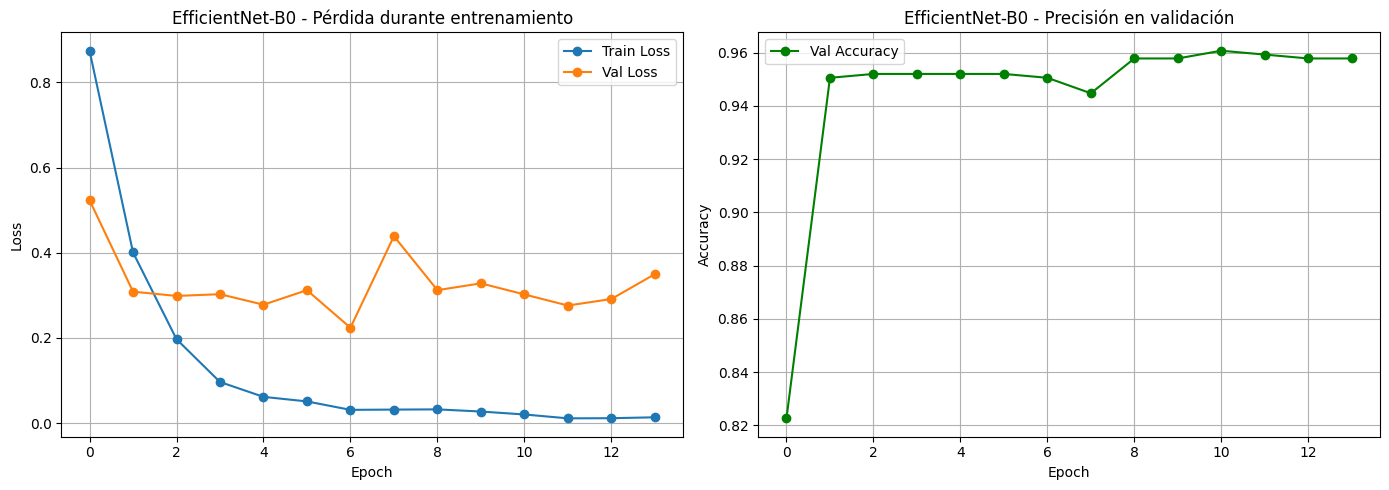

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Gráfico de pérdida
axes[0].plot(train_losses_efficient, label='Train Loss', marker='o')
axes[0].plot(val_losses_efficient, label='Val Loss', marker='o')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('EfficientNet-B0 - Pérdida durante entrenamiento')
axes[0].legend()
axes[0].grid(True)

# Gráfico de precisión
axes[1].plot(val_accuracies_efficient, label='Val Accuracy', marker='o', color='green')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].set_title('EfficientNet-B0 - Precisión en validación')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

## Evaluación en test

In [ ]:
# Cargar mejor modelo
checkpoint = torch.load(f'{SAVE_DIR}/models/best_EfficientNet-B0.pth')
model_efficientnet.load_state_dict(checkpoint['model_state_dict'])

# Evaluar en test
test_loss_efficient, test_acc_efficient, test_preds_efficient, test_labels_efficient, test_probs_efficient = validate_epoch(
    model_efficientnet, test_loader, criterion, DEVICE
)

# Calcular métricas para test
test_precision_efficient = precision_score(test_labels_efficient, test_preds_efficient, zero_division=0)
test_recall_efficient = recall_score(test_labels_efficient, test_preds_efficient, zero_division=0)
test_f1_efficient = f1_score(test_labels_efficient, test_preds_efficient, zero_division=0)
test_auc_efficient = roc_auc_score(test_labels_efficient, test_probs_efficient)
cm_test_efficient = confusion_matrix(test_labels_efficient, test_preds_efficient)
tn, fp, fn, tp = cm_test_efficient.ravel()
test_specificity_efficient = tn / (tn + fp) if (tn + fp) > 0 else 0

print(f"  Loss:         {test_loss_efficient:.4f}")
print(f"  Accuracy:     {test_acc_efficient:.4f}")
print(f"  Precision:    {test_precision_efficient:.4f}")
print(f"  Recall (Sensibilidad): {test_recall_efficient:.4f}")
print(f"  Especificidad: {test_specificity_efficient:.4f}")
print(f"  F1-Score:     {test_f1_efficient:.4f}")
print(f"  AUC-ROC:      {test_auc_efficient:.4f}")

print(f"\nMatriz de confusión:")
print(f"    TN: {cm_test_efficient[0,0]}  FP: {cm_test_efficient[0,1]}")
print(f"    FN: {cm_test_efficient[1,0]}  TP: {cm_test_efficient[1,1]}")

print(f"\nPorcentajes:")
print(f"    Sensibilidad (TPR): {test_recall_efficient*100:.2f}%")
print(f"    Especificidad (TNR): {test_specificity_efficient*100:.2f}%")
print(f"    Precisión (PPV): {test_precision_efficient*100:.2f}%")

  Loss:         0.2423
  Accuracy:     0.9533
  Precision:    0.9012
  Recall (Sensibilidad): 0.9118
  Especificidad: 0.9670
  F1-Score:     0.9064
  AUC-ROC:      0.9877

Matriz de confusión:
    TN: 498  FP: 17
    FN: 15  TP: 155

Porcentajes:
    Sensibilidad (TPR): 91.18%
    Especificidad (TNR): 96.70%
    Precisión (PPV): 90.12%


In [ ]:
import json
import pandas as pd

efficientnet_results = {
    'model': 'EfficientNet-B0',
    'accuracy': test_acc_efficient,
    'precision': test_precision_efficient,
    'recall': test_recall_efficient,
    'specificity': test_specificity_efficient,
    'f1_score': test_f1_efficient,
    'auc_roc': test_auc_efficient,
    'tn': int(cm_test_efficient[0,0]),
    'fp': int(cm_test_efficient[0,1]),
    'fn': int(cm_test_efficient[1,0]),
    'tp': int(cm_test_efficient[1,1])
}

# Guardar como DataFrame
df_results = pd.DataFrame([efficientnet_results])
df_results.to_csv(f'{SAVE_DIR}/results/EfficientNet-B0_results.csv', index=False)

# También guardar como JSON
with open(f'{SAVE_DIR}/results/EfficientNet-B0_results.json', 'w') as f:
    json.dump(efficientnet_results, f, indent=4)

print("Resultados de EfficientNet-B0 guardados automáticamente!")
print("Archivos creados: EfficientNet-B0_results.csv y EfficientNet-B02_results.json")


Resultados de EfficientNet-B0 guardados automáticamente!
Archivos creados: EfficientNet-B0_results.csv y EfficientNet-B02_results.json


# FALTA

# ResNet18 + LSTM

In [ ]:
import torch
import torch.nn as nn
import torchvision.models as models
from torchvision.models import ResNet18_Weights
import numpy as np
import cv2
import os
import gc

class ResNet18LSTM(nn.Module):
    def __init__(self, num_classes=1, lstm_hidden=256, num_layers=2, dropout=0.2):
        super(ResNet18LSTM, self).__init__()

        # ResNet18 pre-entrenado (sin el clasificador final)
        self.resnet = models.resnet18(weights=ResNet18_Weights.IMAGENET1K_V1)
        in_features = self.resnet.fc.in_features
        self.resnet.fc = nn.Identity()  # Eliminar clasificador, solo características

        # LSTM para procesar secuencias
        self.lstm = nn.LSTM(
            input_size=in_features,  # 512 features de ResNet
            hidden_size=lstm_hidden,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0,
            bidirectional=False
        )

        # Capa final de clasificación
        self.fc = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(lstm_hidden, 64),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(64, num_classes)
        )

    def forward(self, x):
        batch_size, seq_len, C, H, W = x.shape
        x = x.view(batch_size * seq_len, C, H, W)
        features = self.resnet(x)
        features = features.view(batch_size, seq_len, -1)
        lstm_out, (hidden, cell) = self.lstm(features)
        last_output = lstm_out[:, -1, :]
        output = self.fc(last_output)
        return output.squeeze(1)

## Modificación del dataset para soportar secuencias

In [ ]:
class LungCancerSequenceDataset(Dataset):
    def __init__(self, dataframe, patch_size=(64, 64, 64), target_size=(224, 224), seq_len=16):
        self.df = dataframe.reset_index(drop=True)
        self.patch_size = patch_size
        self.target_size = target_size
        self.seq_len = seq_len

        self.normalize = transforms.Normalize(
            mean=[0.485, 0.456, 0.406],
            std=[0.229, 0.224, 0.225]
        )

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        path = self.df.iloc[idx]['path']
        label = self.df.iloc[idx]['label']

        # Cargar patch 3D
        if not os.path.exists(path):
            patch = np.zeros((64, 64, 64), dtype=np.float32)
        else:
            patch = np.load(path)  # shape: (64, 64, 64)

        z_center = patch.shape[0] // 2

        #Calcular índices de slices
        total_slices = patch.shape[0]

        # Crear índices espaciados uniformemente alrededor del centro
        half_seq = self.seq_len // 2
        start_idx = max(0, z_center - half_seq)
        end_idx = min(total_slices, z_center + half_seq)

        # Seleccionar índices
        indices = np.linspace(start_idx, end_idx - 1, self.seq_len).astype(int)

        # Extraer slices
        slices = []
        for z in indices:
            axial_slice = patch[z, :, :]
            axial = (axial_slice * 255).astype(np.uint8)
            axial_resized = cv2.resize(axial, self.target_size, interpolation=cv2.INTER_LINEAR)
            axial_norm = axial_resized / 255.0
            slices.append(axial_norm)

        # Convertir a secuencia con 3 canales
        sequence = []
        for slice_img in slices:
            slice_tensor = torch.from_numpy(slice_img).float().unsqueeze(0)
            slice_tensor = slice_tensor.repeat(3, 1, 1)
            slice_tensor = self.normalize(slice_tensor)
            sequence.append(slice_tensor)

        sequence = torch.stack(sequence, dim=0)  # (seq_len, 3, H, W)
        label = torch.tensor(float(label), dtype=torch.float32)

        return sequence, label

## Entrenamiento

In [ ]:
# Limpiar memoria
torch.cuda.empty_cache()
gc.collect()

# Configuración
SEQ_LEN = 16
BATCH_SIZE = 16  # Reducir batch size para LSTM (usa más memoria)

# Crear datasets
train_sequence_dataset = LungCancerSequenceDataset(train_df, seq_len=SEQ_LEN)
val_sequence_dataset = LungCancerSequenceDataset(val_df, seq_len=SEQ_LEN)
test_sequence_dataset = LungCancerSequenceDataset(test_df, seq_len=SEQ_LEN)

print(f"Datasets de secuencias creados")
print(f"  Train: {len(train_sequence_dataset)} muestras")
print(f"  Val: {len(val_sequence_dataset)} muestras")
print(f"  Test: {len(test_sequence_dataset)} muestras")

# Verificar forma
sample_seq, sample_label = train_sequence_dataset[0]
print(f"  Secuencia ejemplo: {sample_seq.shape}")  # (SEQ_LEN, 3, 224, 224)

# DataLoaders (batch_size reducido)
train_loader_seq = DataLoader(
    train_sequence_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

val_loader_seq = DataLoader(
    val_sequence_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

test_loader_seq = DataLoader(
    test_sequence_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

# Crear modelo
model_resnet_lstm = ResNet18LSTM(
    num_classes=1,
    lstm_hidden=256,
    num_layers=2,
    dropout=0.2
).to(DEVICE)

print(f"\nArquitectura ResNet18+LSTM:")
print(f"  Total parameters: {sum(p.numel() for p in model_resnet_lstm.parameters()):,}")

# Test forward
test_input = torch.randn(2, SEQ_LEN, 3, 224, 224).to(DEVICE)
test_output = model_resnet_lstm(test_input)
print(f"  Test forward: {test_input.shape} -> {test_output.shape}")

# Función de pérdida
train_labels = [train_df.iloc[i]['label'] for i in range(len(train_df))]
num_neg = train_labels.count(0)
num_pos = train_labels.count(1)
pos_weight_value = num_neg / num_pos

criterion = nn.BCEWithLogitsLoss(
    pos_weight=torch.tensor([pos_weight_value]).to(DEVICE)
)

optimizer_lstm = torch.optim.Adam(model_resnet_lstm.parameters(), lr=LEARNING_RATE)
scheduler_lstm = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer_lstm, mode='min', factor=0.5, patience=3
)

Datasets de secuencias creados
  Train: 3307 muestras
  Val: 688 muestras
  Test: 685 muestras
  Secuencia ejemplo: torch.Size([16, 3, 224, 224])

Arquitectura ResNet18+LSTM:
  Total parameters: 12,507,841
  Test forward: torch.Size([2, 16, 3, 224, 224]) -> torch.Size([2])


## Funciones

In [ ]:
def train_epoch_seq(model, loader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for sequences, labels in loader:
        sequences, labels = sequences.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(sequences)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * sequences.size(0)
        preds = (torch.sigmoid(outputs) > 0.5).float()
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    return running_loss / len(loader.dataset), correct / total


def validate_epoch_seq(model, loader, criterion, device):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0
    all_preds = []
    all_labels = []
    all_probs = []

    with torch.no_grad():
        for sequences, labels in loader:
            sequences, labels = sequences.to(device), labels.to(device)
            outputs = model(sequences)
            loss = criterion(outputs, labels)

            running_loss += loss.item() * sequences.size(0)
            probs = torch.sigmoid(outputs)
            preds = (probs > 0.5).float()
            correct += (preds == labels).sum().item()
            total += labels.size(0)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
            all_probs.extend(probs.cpu().numpy())

    return (running_loss / len(loader.dataset),
            correct / total,
            all_preds, all_labels, all_probs)

## Bucle de entrenamiento

In [ ]:
train_losses_lstm = []
val_losses_lstm = []
val_accuracies_lstm = []
best_val_loss_lstm = float('inf')
patience_counter_lstm = 0

for epoch in range(NUM_EPOCHS):
    train_loss, train_acc = train_epoch_seq(model_resnet_lstm, train_loader_seq,
                                             criterion, optimizer_lstm, DEVICE)

    val_loss, val_acc, preds, labels, probs = validate_epoch_seq(
        model_resnet_lstm, val_loader_seq, criterion, DEVICE
    )

    # Métricas
    from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix
    precision = precision_score(labels, preds, zero_division=0)
    recall = recall_score(labels, preds, zero_division=0)
    f1 = f1_score(labels, preds, zero_division=0)
    cm = confusion_matrix(labels, preds)
    tn, fp, fn, tp = cm.ravel()
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0

    train_losses_lstm.append(train_loss)
    val_losses_lstm.append(val_loss)
    val_accuracies_lstm.append(val_acc)

    print(f"\nEpoch {epoch+1}/{NUM_EPOCHS}")
    print(f"  Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f}")
    print(f"  Val Loss:   {val_loss:.4f} | Val Acc:   {val_acc:.4f}")
    print(f"  Precision: {precision:.4f} | Sensibilidad: {recall:.4f} | Especificidad: {specificity:.4f} | F1: {f1:.4f}")

    scheduler_lstm.step(val_loss)

    if val_loss < best_val_loss_lstm:
        best_val_loss_lstm = val_loss
        patience_counter_lstm = 0
        torch.save({
            'epoch': epoch,
            'model_state_dict': model_resnet_lstm.state_dict(),
            'optimizer_state_dict': optimizer_lstm.state_dict(),
            'val_loss': best_val_loss_lstm,
        },f'{SAVE_DIR}/models/best_ResNet18+LSTM.pth')
    else:
        patience_counter_lstm += 1
        if patience_counter_lstm >= 7:
            print(f"Early stopping en epoch {epoch+1}")
            break

print(f"\nMejor modelo ResNet18+LSTM con val_loss: {best_val_loss_lstm:.4f}")



Epoch 1/20
  Train Loss: 0.8114 | Train Acc: 0.6946
  Val Loss:   0.4606 | Val Acc:   0.8576
  Precision: 0.6692 | Sensibilidad: 0.9468 | Especificidad: 0.8240 | F1: 0.7841

Epoch 2/20
  Train Loss: 0.3492 | Train Acc: 0.9117
  Val Loss:   0.2284 | Val Acc:   0.9390
  Precision: 0.8544 | Sensibilidad: 0.9362 | Especificidad: 0.9400 | F1: 0.8934

Epoch 3/20
  Train Loss: 0.1817 | Train Acc: 0.9595
  Val Loss:   0.3251 | Val Acc:   0.9012
  Precision: 0.7479 | Sensibilidad: 0.9628 | Especificidad: 0.8780 | F1: 0.8419

Epoch 4/20
  Train Loss: 0.1556 | Train Acc: 0.9625
  Val Loss:   0.1939 | Val Acc:   0.9651
  Precision: 0.9505 | Sensibilidad: 0.9202 | Especificidad: 0.9820 | F1: 0.9351

Epoch 5/20
  Train Loss: 0.0882 | Train Acc: 0.9794
  Val Loss:   0.2140 | Val Acc:   0.9651
  Precision: 0.9316 | Sensibilidad: 0.9415 | Especificidad: 0.9740 | F1: 0.9365

Epoch 6/20
  Train Loss: 0.1100 | Train Acc: 0.9743
  Val Loss:   0.1078 | Val Acc:   0.9767
  Precision: 0.9479 | Sensibilidad: 

## Evaluación en test

In [ ]:
# Cargar mejor modelo
checkpoint = torch.load(f'{SAVE_DIR}/models/best_ResNet18+LSTM.pth', weights_only=False)
model_resnet_lstm.load_state_dict(checkpoint['model_state_dict'])

# Evaluar en test
test_loss_lstm, test_acc_lstm, test_preds_lstm, test_labels_lstm, test_probs_lstm = validate_epoch_seq(
    model_resnet_lstm, test_loader_seq, criterion, DEVICE
)

# Calcular métricas
test_precision_lstm = precision_score(test_labels_lstm, test_preds_lstm, zero_division=0)
test_recall_lstm = recall_score(test_labels_lstm, test_preds_lstm, zero_division=0)
test_f1_lstm = f1_score(test_labels_lstm, test_preds_lstm, zero_division=0)
test_auc_lstm = roc_auc_score(test_labels_lstm, test_probs_lstm)
cm_test_lstm = confusion_matrix(test_labels_lstm, test_preds_lstm)
tn, fp, fn, tp = cm_test_lstm.ravel()
test_specificity_lstm = tn / (tn + fp) if (tn + fp) > 0 else 0

print("\n" + "="*60)
print("RESULTADOS RESNET18+LSTM - CONJUNTO DE TEST")
print("="*60)
print(f"  Loss:         {test_loss_lstm:.4f}")
print(f"  Accuracy:     {test_acc_lstm:.4f}")
print(f"  Precision:    {test_precision_lstm:.4f}")
print(f"  Recall (Sensibilidad): {test_recall_lstm:.4f}")
print(f"  Especificidad: {test_specificity_lstm:.4f}")
print(f"  F1-Score:     {test_f1_lstm:.4f}")
print(f"  AUC-ROC:      {test_auc_lstm:.4f}")

print(f"\nMatriz de confusión:")
print(f"    TN: {cm_test_lstm[0,0]}  FP: {cm_test_lstm[0,1]}")
print(f"    FN: {cm_test_lstm[1,0]}  TP: {cm_test_lstm[1,1]}")

print(f"\nPorcentajes:")
print(f"    Sensibilidad (TPR): {test_recall_lstm*100:.2f}%")
print(f"    Especificidad (TNR): {test_specificity_lstm*100:.2f}%")
print(f"    Precisión (PPV): {test_precision_lstm*100:.2f}%")


RESULTADOS RESNET18+LSTM - CONJUNTO DE TEST
  Loss:         0.1618
  Accuracy:     0.9708
  Precision:    0.9360
  Recall (Sensibilidad): 0.9471
  Especificidad: 0.9786
  F1-Score:     0.9415
  AUC-ROC:      0.9936

Matriz de confusión:
    TN: 504  FP: 11
    FN: 9  TP: 161

Porcentajes:
    Sensibilidad (TPR): 94.71%
    Especificidad (TNR): 97.86%
    Precisión (PPV): 93.60%


In [ ]:
import json
import pandas as pd

resnet_lstm_results = {
    'model': 'ResNet18+LSTM',
    'accuracy': float(test_acc_lstm),
    'precision': float(test_precision_lstm),
    'recall': float(test_recall_lstm),
    'specificity': float(test_specificity_lstm),
    'f1_score': float(test_f1_lstm),
    'auc_roc': float(test_auc_lstm),
    'tn': int(cm_test_lstm[0,0]),
    'fp': int(cm_test_lstm[0,1]),
    'fn': int(cm_test_lstm[1,0]),
    'tp': int(cm_test_lstm[1,1])
}

# Guardar como DataFrame
df_results = pd.DataFrame([resnet_lstm_results])
df_results.to_csv(f'{SAVE_DIR}/results/ResNet18_LSTM_results.csv', index=False)

# También guardar como JSON
with open(f'{SAVE_DIR}/results/ResNet18_LSTM_results.json', 'w') as f:
    json.dump(resnet_lstm_results, f, indent=4)

print("Resultados de ResNet18_LSTM_results guardados automáticamente!")
print("Archivos creados: ResNet18_LSTM_results.csv y ResNet18_LSTM_results.json")


Resultados de ResNet18_LSTM_results guardados automáticamente!
Archivos creados: ResNet18_LSTM_results.csv y ResNet18_LSTM_results.json


# Gráficos de los modelos

In [ ]:
def generar_graficos(model_name, train_losses, val_losses, val_accuracies,
                          test_labels, test_preds, test_probs,
                          test_acc, test_recall, test_specificity,
                          test_precision, test_f1, test_auc, cm_test,
                          SAVE_DIR):

    import os
    import numpy as np
    import matplotlib.pyplot as plt
    import seaborn as sns
    from sklearn.metrics import roc_curve, auc, precision_recall_curve, average_precision_score, confusion_matrix
    import pandas as pd
    import math

    # Configuración para IEEE
    plt.rcParams['font.family'] = 'serif'
    plt.rcParams['font.size'] = 10
    plt.rcParams['axes.labelsize'] = 11
    plt.rcParams['axes.titlesize'] = 12
    plt.rcParams['legend.fontsize'] = 9
    plt.rcParams['figure.dpi'] = 300

    # Crear directorio
    model_dir = os.path.join(SAVE_DIR, 'plots', model_name)
    os.makedirs(model_dir, exist_ok=True)

    blues = {
        'dark': '#0d3b66',      # Azul oscuro
        'medium': '#1f77b4',    # Azul medio
        'light': '#4a90e2',     # Azul claro
        'lighter': '#7bb3e8',   # Azul más claro
        'lightest': '#a8c9f0',  # Azul muy claro
        'gray': '#7f7f7f',      # Gris para referencias
        'black': '#000000'      # Negro
    }

    # ============================================
    # GRÁFICO 1: Curvas de Pérdida
    # ============================================
    print("Gráfico 1: Curvas de pérdida...")
    fig, ax = plt.subplots(figsize=(8, 5))
    epochs = range(1, len(train_losses) + 1)

    ax.plot(epochs, train_losses, 'o-', color=blues['medium'], linewidth=1.5,
            markersize=4, label='Training Loss', markeredgecolor='black', markeredgewidth=0.5)
    ax.plot(epochs, val_losses, 's-', color=blues['dark'], linewidth=1.5,
            markersize=4, label='Validation Loss', markeredgecolor='black', markeredgewidth=0.5)

    best_epoch = val_losses.index(min(val_losses)) + 1
    ax.axvline(x=best_epoch, color=blues['gray'], linestyle='--', linewidth=1, alpha=0.7)
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Loss')
    ax.set_title(f'{model_name} - Training and Validation Loss')
    ax.legend(loc='upper right')
    ax.grid(True, alpha=0.3, linestyle='--')
    ax.set_facecolor('#f8f9fa')
    plt.tight_layout()
    plt.savefig(f'{SAVE_DIR}/plots/{model_name}/1_loss_curves.png', dpi=300, bbox_inches='tight', facecolor='white')
    plt.close()

    # ============================================
    # GRÁFICO 2: Accuracy
    # ============================================
    print("Gráfico 2: Accuracy...")
    fig, ax = plt.subplots(figsize=(8, 5))
    ax.plot(epochs, val_accuracies, 'o-', color=blues['medium'], linewidth=1.5,
            markersize=4, label='Validation Accuracy', markeredgecolor='black', markeredgewidth=0.5)
    best_acc = max(val_accuracies)
    ax.axhline(y=best_acc, color=blues['gray'], linestyle='--', linewidth=1, alpha=0.7)
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Accuracy')
    ax.set_title(f'{model_name} - Validation Accuracy')
    ax.legend(loc='lower right')
    ax.grid(True, alpha=0.3, linestyle='--')
    ax.set_ylim([0, 1.05])
    ax.set_facecolor('#f8f9fa')
    plt.tight_layout()
    plt.savefig(f'{SAVE_DIR}/plots/{model_name}/2_validation_accuracy.png', dpi=300, bbox_inches='tight', facecolor='white')
    plt.close()

    # ============================================
    # GRÁFICO 3: Curva ROC
    # ============================================
    print("Gráfico 3: Curva ROC...")
    fpr, tpr, _ = roc_curve(test_labels, test_probs)
    roc_auc = test_auc
    fig, ax = plt.subplots(figsize=(7, 7))
    ax.plot(fpr, tpr, color=blues['medium'], linewidth=2, label=f'{model_name} (AUC = {roc_auc:.3f})')
    ax.plot([0, 1], [0, 1], color=blues['gray'], linestyle='--', linewidth=1, label='Random Classifier')
    ax.fill_between(fpr, tpr, alpha=0.15, color=blues['medium'])
    ax.set_xlim([0.0, 1.0])
    ax.set_ylim([0.0, 1.05])
    ax.set_xlabel('False Positive Rate')
    ax.set_ylabel('True Positive Rate')
    ax.set_title(f'{model_name} - ROC Curve')
    ax.legend(loc='lower right')
    ax.grid(True, alpha=0.3, linestyle='--')
    ax.set_facecolor('#f8f9fa')
    plt.tight_layout()
    plt.savefig(f'{SAVE_DIR}/plots/{model_name}/3_roc_curve.png', dpi=300, bbox_inches='tight', facecolor='white')
    plt.close()

    # ============================================
    # GRÁFICO 4: Matriz de Confusión (escala de azules)
    # ============================================
    print("Gráfico 4: Matriz de confusión...")
    cm = cm_test
    cm_percent = cm / cm.sum() * 100
    fig, ax = plt.subplots(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Negative', 'Positive'],
                yticklabels=['Negative', 'Positive'],
                ax=ax, cbar_kws={'label': 'Count', 'shrink': 0.8})
    for i in range(2):
        for j in range(2):
            ax.text(j+0.5, i+0.7, f'({cm_percent[i,j]:.1f}%)',
                    ha='center', va='center', fontsize=9, color='black')
    ax.set_xlabel('Predicted Label')
    ax.set_ylabel('True Label')
    ax.set_title(f'{model_name} - Confusion Matrix')
    plt.tight_layout()
    plt.savefig(f'{SAVE_DIR}/plots/{model_name}/4_confusion_matrix.png', dpi=300, bbox_inches='tight', facecolor='white')
    plt.close()

    # ============================================
    # GRÁFICO 5: Barras de Métricas (solo azules)
    # ============================================
    print("Gráfico 5: Barras de métricas...")
    metrics = ['Accuracy', 'Sensitivity', 'Specificity', 'Precision', 'F1-Score', 'AUC-ROC']
    values = [test_acc, test_recall, test_specificity, test_precision, test_f1, test_auc]
    # Gradiente de azules
    blue_gradient = [blues['dark'], blues['medium'], blues['medium'], blues['light'], blues['lighter'], blues['lightest']]
    fig, ax = plt.subplots(figsize=(10, 5))
    bars = ax.bar(metrics, values, color=blue_gradient, edgecolor='black', linewidth=0.8)
    ax.axhline(y=0.85, color=blues['gray'], linestyle='--', linewidth=1, alpha=0.7, label='Clinical Threshold (85%)')
    for bar, value in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                f'{value:.3f}', ha='center', va='bottom', fontsize=9)
    ax.set_ylim(0, 1.1)
    ax.set_ylabel('Score')
    ax.set_title(f'{model_name} - Performance Metrics')
    ax.legend(loc='upper right')
    ax.grid(True, alpha=0.3, axis='y', linestyle='--')
    ax.set_facecolor('#f8f9fa')
    plt.tight_layout()
    plt.savefig(f'{SAVE_DIR}/plots/{model_name}/5_metrics_bars.png', dpi=300, bbox_inches='tight', facecolor='white')
    plt.close()

    # ============================================
    # GRÁFICO 6: Distribución de Probabilidades
    # ============================================
    print("Gráfico 6: Distribución de probabilidades...")
    pos_probs = [test_probs[i] for i in range(len(test_labels)) if test_labels[i] == 1]
    neg_probs = [test_probs[i] for i in range(len(test_labels)) if test_labels[i] == 0]
    fig, ax = plt.subplots(figsize=(8, 5))
    ax.hist(neg_probs, bins=30, alpha=0.6, color=blues['light'], label=f'Healthy (n={len(neg_probs)})',
            density=True, edgecolor='black', histtype='stepfilled')
    ax.hist(pos_probs, bins=30, alpha=0.8, color=blues['dark'], label=f'Cancer (n={len(pos_probs)})',
            density=True, edgecolor='black', histtype='stepfilled')
    ax.axvline(x=0.5, color='black', linestyle='--', linewidth=1.5, label='Threshold (0.5)')
    ax.set_xlabel('Predicted Probability of Cancer')
    ax.set_ylabel('Density')
    ax.set_title(f'{model_name} - Probability Distribution')
    ax.legend(loc='upper center')
    ax.grid(True, alpha=0.3, linestyle='--')
    ax.set_facecolor('#f8f9fa')
    plt.tight_layout()
    plt.savefig(f'{SAVE_DIR}/plots/{model_name}/6_probability_distribution.png', dpi=300, bbox_inches='tight', facecolor='white')
    plt.close()

    # ============================================
    # GRÁFICO 7: Curva Precisión-Recall
    # ============================================
    print("Gráfico 7: Curva Precisión-Recall...")
    precision_curve, recall_curve, _ = precision_recall_curve(test_labels, test_probs)
    avg_precision = average_precision_score(test_labels, test_probs)
    fig, ax = plt.subplots(figsize=(7, 7))
    ax.plot(recall_curve, precision_curve, color=blues['medium'], linewidth=2, label=f'{model_name} (AP = {avg_precision:.3f})')
    ax.fill_between(recall_curve, precision_curve, alpha=0.15, color=blues['medium'])
    ax.set_xlim([0.0, 1.0])
    ax.set_ylim([0.0, 1.05])
    ax.set_xlabel('Recall (Sensitivity)')
    ax.set_ylabel('Precision (PPV)')
    ax.set_title(f'{model_name} - Precision-Recall Curve')
    ax.legend(loc='lower left')
    ax.grid(True, alpha=0.3, linestyle='--')
    ax.set_facecolor('#f8f9fa')
    plt.tight_layout()
    plt.savefig(f'{SAVE_DIR}/plots/{model_name}/7_precision_recall_curve.png', dpi=300, bbox_inches='tight', facecolor='white')
    plt.close()

    # ============================================
    # GRÁFICO 8: Boxplot (solo azules)
    # ============================================
    print("Gráfico 8: Boxplot...")
    fig, ax = plt.subplots(figsize=(6, 5))
    data_to_plot = [neg_probs, pos_probs]
    bp = ax.boxplot(data_to_plot, tick_labels=['Healthy', 'Cancer'],
                    patch_artist=True, showmeans=True, meanline=True)
    bp['boxes'][0].set_facecolor(blues['light'])
    bp['boxes'][1].set_facecolor(blues['medium'])
    bp['boxes'][0].set_alpha(0.7)
    bp['boxes'][1].set_alpha(0.7)
    bp['medians'][0].set_color('black')
    bp['medians'][1].set_color('black')
    bp['medians'][0].set_linewidth(1.5)
    bp['medians'][1].set_linewidth(1.5)
    bp['means'][0].set_marker('D')
    bp['means'][1].set_marker('D')
    ax.axhline(y=0.5, color='black', linestyle='--', linewidth=1, label='Threshold (0.5)')
    ax.set_ylabel('Predicted Probability')
    ax.set_title(f'{model_name} - Prediction Distribution')
    ax.legend()
    ax.grid(True, alpha=0.3, axis='y', linestyle='--')
    ax.set_facecolor('#f8f9fa')
    plt.tight_layout()
    plt.savefig(f'{SAVE_DIR}/plots/{model_name}/8_boxplot.png', dpi=300, bbox_inches='tight', facecolor='white')
    plt.close()

    # ============================================
    # GRÁFICO 9: Análisis de Errores (solo azules)
    # ============================================
    print("Gráfico 9: Análisis de errores...")
    errors_df = pd.DataFrame({
        'True Label': test_labels,
        'Predicted': test_preds,
        'Probability': test_probs
    })
    errors_df['Error Type'] = errors_df.apply(
        lambda x: 'False Positive' if x['True Label']==0 and x['Predicted']==1 else
                  ('False Negative' if x['True Label']==1 and x['Predicted']==0 else 'Correct'),
        axis=1
    )
    fig, ax = plt.subplots(figsize=(8, 5))
    fp_probs = errors_df[errors_df['Error Type']=='False Positive']['Probability']
    fn_probs = errors_df[errors_df['Error Type']=='False Negative']['Probability']
    ax.hist(fp_probs, bins=20, alpha=0.6, color=blues['light'], label=f'False Positives (n={len(fp_probs)})', edgecolor='black')
    ax.hist(fn_probs, bins=20, alpha=0.8, color=blues['dark'], label=f'False Negatives (n={len(fn_probs)})', edgecolor='black')
    ax.axvline(x=0.5, color='black', linestyle='--', linewidth=1, label='Threshold')
    ax.set_xlabel('Predicted Probability')
    ax.set_ylabel('Frequency')
    ax.set_title(f'{model_name} - Error Analysis')
    ax.legend()
    ax.grid(True, alpha=0.3, linestyle='--')
    ax.set_facecolor('#f8f9fa')
    plt.tight_layout()
    plt.savefig(f'{SAVE_DIR}/plots/{model_name}/9_error_analysis.png', dpi=300, bbox_inches='tight', facecolor='white')
    plt.close()

    # ============================================
    # GRÁFICO 10: Radar Chart (solo azul)
    # ============================================
    print("Gráfico 10: Radar chart...")
    categories = ['Accuracy', 'Sensitivity', 'Specificity', 'Precision', 'F1-Score']
    values_radar = [test_acc, test_recall, test_specificity, test_precision, test_f1]
    values_radar += values_radar[:1]
    angles = [n / float(len(categories)) * 2 * math.pi for n in range(len(categories))]
    angles += angles[:1]
    fig, ax = plt.subplots(figsize=(7, 7), subplot_kw=dict(projection='polar'))
    ax.plot(angles, values_radar, 'o-', linewidth=1.5, color=blues['medium'], label=model_name)
    ax.fill(angles, values_radar, alpha=0.15, color=blues['medium'])
    ideal = [1] * len(categories)
    ideal += ideal[:1]
    ax.plot(angles, ideal, '--', linewidth=0.8, color=blues['gray'], alpha=0.7, label='Ideal (1.0)')
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(categories, size=9)
    ax.set_ylim(0, 1)
    ax.set_title(f'{model_name} - Metrics Radar Chart', size=11)
    ax.legend(loc='upper right', bbox_to_anchor=(1.1, 1.0))
    ax.grid(True)
    plt.tight_layout()
    plt.savefig(f'{SAVE_DIR}/plots/{model_name}/10_radar_chart.png', dpi=300, bbox_inches='tight', facecolor='white')
    plt.close()

    print(f"\nGráficos guardados en: {SAVE_DIR}/plots/{model_name}/")

In [ ]:
# Para MOBILENETV2
generar_graficos(
    'MobileNetV2',
    train_losses, val_losses, val_accuracies,
    test_labels, test_preds, test_probs,
    test_acc, test_recall, test_specificity,
    test_precision, test_f1, test_auc, cm_test,
    SAVE_DIR
)

# Para DENSENET121
generar_graficos(
    'DenseNet121',
    train_losses_dense, val_losses_dense, val_accuracies_dense,
    test_labels_dense, test_preds_dense, test_probs_dense,
    test_acc_dense, test_recall_dense, test_specificity_dense,
    test_precision_dense, test_f1_dense, test_auc_dense, cm_test_dense,
    SAVE_DIR
)

# Para EFFICIENTNET-B0
generar_graficos(
    'EfficientNet-B0',
    train_losses_efficient, val_losses_efficient, val_accuracies_efficient,
    test_labels_efficient, test_preds_efficient, test_probs_efficient,
    test_acc_efficient, test_recall_efficient, test_specificity_efficient,
    test_precision_efficient, test_f1_efficient, test_auc_efficient, cm_test_efficient,
    SAVE_DIR
)

# Para RESNET18+LSTM
generar_graficos(
    'ResNet18+LSTM',
    train_losses_lstm, val_losses_lstm, val_accuracies_lstm,
    test_labels_lstm, test_preds_lstm, test_probs_lstm,
    test_acc_lstm, test_recall_lstm, test_specificity_lstm,
    test_precision_lstm, test_f1_lstm, test_auc_lstm, cm_test_lstm,
    SAVE_DIR
)

Gráfico 1: Curvas de pérdida...
Gráfico 2: Accuracy...
Gráfico 3: Curva ROC...
Gráfico 4: Matriz de confusión...
Gráfico 5: Barras de métricas...
Gráfico 6: Distribución de probabilidades...
Gráfico 7: Curva Precisión-Recall...
Gráfico 8: Boxplot...
Gráfico 9: Análisis de errores...
Gráfico 10: Radar chart...

Gráficos guardados en: /content/drive/MyDrive/INTRUSA JIJIJI/Modelos_DL/plots/MobileNetV2/
Gráfico 1: Curvas de pérdida...
Gráfico 2: Accuracy...
Gráfico 3: Curva ROC...
Gráfico 4: Matriz de confusión...
Gráfico 5: Barras de métricas...
Gráfico 6: Distribución de probabilidades...
Gráfico 7: Curva Precisión-Recall...
Gráfico 8: Boxplot...
Gráfico 9: Análisis de errores...
Gráfico 10: Radar chart...

Gráficos guardados en: /content/drive/MyDrive/INTRUSA JIJIJI/Modelos_DL/plots/DenseNet121/
Gráfico 1: Curvas de pérdida...
Gráfico 2: Accuracy...
Gráfico 3: Curva ROC...
Gráfico 4: Matriz de confusión...
Gráfico 5: Barras de métricas...
Gráfico 6: Distribución de probabilidades...
Grá

In [5]:
import os

results_dir = f"{SAVE_DIR}/results"

for file in os.listdir(results_dir):
    print(file)

MobileNetV2_results.csv
MobileNetV2_results.json
DenseNet121_results.csv
DenseNet121_results.json
EfficientNet-B0_results.csv
EfficientNet-B0_results.json
ResNet18_LSTM_results.json
ResNet18_LSTM_results.csv


In [6]:
import json

with open(f"{SAVE_DIR}/results/MobileNetV2_results.json", "r") as f:
    data = json.load(f)

print(data)

{'model': 'MobileNetV2', 'accuracy': 0.9416058394160584, 'precision': 0.8869047619047619, 'recall': 0.8764705882352941, 'specificity': 0.9631067961165048, 'f1_score': 0.8816568047337278, 'auc_roc': 0.9775328383780697, 'tn': 496, 'fp': 19, 'fn': 21, 'tp': 149}


In [7]:
import json
import pandas as pd
import os

results_dir = f"{SAVE_DIR}/results"

json_files = [
    "MobileNetV2_results.json",
    "DenseNet121_results.json",
    "EfficientNet-B0_results.json",
    "ResNet18_LSTM_results.json"
]

resultados = []

for file in json_files:

    with open(os.path.join(results_dir, file), "r") as f:
        data = json.load(f)

    resultados.append({
        "Modelo": data["model"],
        "Accuracy": data["accuracy"],
        "Precision": data["precision"],
        "Recall": data["recall"],
        "Specificity": data["specificity"],
        "F1-Score": data["f1_score"],
        "AUC-ROC": data["auc_roc"]
    })

comparison_df = pd.DataFrame(resultados)

comparison_df = comparison_df.sort_values(
    by="AUC-ROC",
    ascending=False
)

comparison_df

,Modelo,Accuracy,Precision,Recall,Specificity,F1-Score,AUC-ROC
3,ResNet18+LSTM,0.970803,0.936047,0.947059,0.978641,0.941520,0.993604
2,EfficientNet-B0,0.953285,0.901163,0.911765,0.966990,0.906433,0.987721
1,DenseNet121,0.951825,0.895954,0.911765,0.965049,0.903790,0.982890
0,MobileNetV2,0.941606,0.886905,0.876471,0.963107,0.881657,0.977533
